In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'
SAVE_PATH_3 = "TRAINED/GMAN_model_reconstruct.pth"

SAMPLING = '1h'
MONTHS_HISTORY = 8

# CREATION GRAPH

In [2]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [3]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,2.64,2.64,14.03,14.03,2.64,2.21,11.39,9.43,0.74,0.43,0.92,0.54,7.22,1.90,0.07,0.74
2024-01-01 01:00:00,0.92,0.92,12.47,12.47,0.92,0.92,11.55,9.59,0.00,0.00,0.92,0.00,8.67,1.90,0.07,0.00
2024-01-01 02:00:00,2.78,2.78,18.98,18.98,2.78,2.78,16.20,12.89,2.23,0.00,0.00,0.54,10.11,3.32,0.00,2.23
2024-01-01 03:00:00,8.29,8.29,30.18,30.18,8.29,7.00,21.90,20.00,2.23,1.29,3.68,1.08,13.00,1.90,0.00,2.23
2024-01-01 04:00:00,12.40,12.40,58.18,58.18,12.40,10.90,45.78,38.34,5.21,1.50,4.60,1.08,27.44,7.11,0.33,5.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,1563.59,1563.59,3418.78,3418.78,1563.59,1319.68,1855.19,1748.30,338.66,243.91,135.12,845.89,428.62,44.86,62.02,338.66
2024-06-28 20:00:00,1352.29,1352.29,2844.74,2844.74,1352.29,1209.79,1492.45,1429.17,240.36,142.50,71.43,898.00,219.38,31.15,32.14,240.36
2024-06-28 21:00:00,944.09,944.09,1948.89,1948.89,944.09,878.56,1004.81,979.81,91.71,65.53,35.49,751.36,101.25,13.44,11.56,91.71
2024-06-28 22:00:00,355.94,355.94,722.02,722.02,355.94,336.18,366.08,359.81,25.18,19.76,6.82,304.18,23.62,3.17,3.10,25.18


# GMAN MATRICES

In [4]:
def get_line_adjacency_matrix(G, NODE_LIST):
    """
    Returns the adjacency matrix of G_line as a numpy array, 
    preserving the order specified in NODE_LIST.
    """
    return nx.to_numpy_array(G, nodelist=NODE_LIST)

ADJ_MATRIX = get_line_adjacency_matrix(G_router, NODE_LIST)
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=NODE_LIST, index=NODE_LIST).astype(int)
print("Adjacency Matrix:")
ADJ_MATRIX_DF

Adjacency Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MR_A,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
HR_B,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
MR_B,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
A,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
B,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
S7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
def build_node_conservation_matrix(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels

INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix(G_router, NODE_LIST)
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=NODE_LIST, index=row_labels)
print("Incidence Matrix:")
display(INCIDENCE_MATRIX_DF)

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)
Incidence Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


The average loss is: 1.1663864318833817e-14


In [6]:
if DEBUG:
    _flows_results = []
    for _ in range(100):
        _rand_flow = DATA_RAW_MODEL.sample(1)

        _flow_test = torch.tensor(_rand_flow.to_numpy()).float().view(-1, 1)

        _incidence_m = INCIDENCE_MATRIX
        _incidence_m = torch.tensor(_incidence_m).float()
        _incidence_m

        _flow_kirchoffs = torch.matmul(_incidence_m, _flow_test)
        _flows_results.append(_flow_kirchoffs)

    _result = sum([x.sum() for x in _flows_results])/len(_flows_results)
    print("The sum of the flow kirchoffs is: {}".format(_result))


The sum of the flow kirchoffs is: 9.287297871196643e-05


In [7]:

INNER_NODES_MASK =  (INCIDENCE_MATRIX_DF == 1).sum()
LEAF_NODES_MASK = (INNER_NODES_MASK == 0)*1

print(f"INNER_NODES_MASK: {INNER_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.iloc[i]])
print()
print(f"LEAF_NODES_MASK: {LEAF_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.iloc[i]])

INNER_NODES_MASK: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

LEAF_NODES_MASK: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']


In [8]:
def generate_node_reconstruction_mask_numpy(G_physical, node_list, k_hops=2):
    """
    Generates a Node-to-Node Spatial Attention Mask as a NumPy array.
    
    Args:
        G_physical (nx.DiGraph): The router-to-router graph.
        node_list (list): The EXACT list of nodes in the desired order. 
        k_hops (int): Depth of vision (how far downstream to look).
        
    Returns:
        np.ndarray: Shape [N, N], dtype=bool.
                    True  = Blocked / Masked (Cannot attend).
                    False = Visible / Allowed (Can attend).
    """
    num_nodes = len(node_list)
    print(f"--- Generating Ordered Node Mask (NumPy) ---")
    
    # 1. Create Mapping
    # Ensures Row 0 is node_list[0], Row 1 is node_list[1]...
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    
    # 2. Initialize Mask
    # Default is True (Blocked/Hidden)
    mask = np.ones((num_nodes, num_nodes), dtype=bool)
    
    # 3. Build Connectivity
    for i, u in enumerate(node_list):
        
        if u not in G_physical:
            print(f"⚠️ Warning: Node '{u}' not found in graph.")
            continue
            
        # A. Self-Attention (Always Allow)
            mask[i, i] = False

        
        # B. Downstream Lookup
        try:
            # Find all nodes 'v' reachable from 'u' within k_hops
            descendants = nx.single_source_shortest_path_length(G_physical, u, cutoff=k_hops)
            
            for v in descendants:
                if v in node_to_idx:
                    j = node_to_idx[v]
                    mask[i, j] = False # Make visible
            
            #if re.match(r'S\d+', u):
            #    mask[i, i] = False
            #else:
            #    mask[i, i] = True 
                    
        except Exception as e:
            print(f"Error processing node {u}: {e}")

   
    # Stats
    total_cells = num_nodes * num_nodes
    visible_cells = (~mask).sum() # Count False values
    print(f"✅ Mask Created. Shape ({num_nodes}, {num_nodes}). Visible Connections: {visible_cells}")
    
    return mask


ATT_MASK = generate_node_reconstruction_mask_numpy(G_router, NODE_LIST, k_hops=1)
ATT_MASK_DF = pd.DataFrame(ATT_MASK, columns=NODE_LIST, index=NODE_LIST)*1
print("Reconstruction Attention Mask:")
ATT_MASK_DF

--- Generating Ordered Node Mask (NumPy) ---
✅ Mask Created. Shape (16, 16). Visible Connections: 32
Reconstruction Attention Mask:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1
MR_A,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1
HR_B,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1
MR_B,1,0,1,0,1,1,0,1,1,1,1,1,1,1,1,1
C,1,1,1,1,0,0,1,1,1,0,1,1,1,1,1,1
D,1,1,1,1,1,0,1,1,0,1,0,0,1,1,1,1
A,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,1
B,1,1,1,1,1,0,1,0,1,1,1,1,0,1,1,1
E,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,0
S7,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1


# PARAMETERS

In [10]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(2*(24/FREQ_H))          # 2 days
PRED_STEPS = int(1*(24/FREQ_H))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 32

STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 1 hours
Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 48
Number of prediction steps: 24
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 32
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 8


# DATASETS / DATALOADERS

In [11]:
class NetworkTrafficDataset(Dataset):
    def __init__(self, dataframe, num_his, num_pred, time_slot_hours=1, mean=None, std=None, is_inference=False):
        """
        dataframe:     Pandas DataFrame where Rows=Time, Cols=Nodes (Traffic Speed/Volume).
        num_his:       Number of historical steps (P).
        num_pred:      Number of prediction steps (Q).
        time_slot_min: Granularity of data in minutes (e.g., 5-minute intervals).
        mean, std:     Pre-calculated stats (pass these from the Training set when making Val/Test sets).
        """
        # Convert dataframe to numpy float32
        self.data = dataframe.values.astype(np.float32)
        self.num_his = num_his
        self.num_pred = num_pred
        self.is_inference = is_inference # Save the flag
        
        # --- 1. Create Temporal Embeddings (TE) ---
        time_index = pd.to_datetime(dataframe.index)
        
        # Calculate maximum steps per day based on granularity
        self.steps_per_day = (24) // time_slot_hours
        
        # Extract calendar features
        dow = time_index.dayofweek.values.reshape(-1, 1) # Day of Week (0-6)
        tod = ((time_index.hour) // time_slot_hours).values.reshape(-1, 1) # Time of Day (0 to steps_per_day-1)
        moy = time_index.month.values.reshape(-1, 1) # Month of Year (1-12)
        
        # Combine into a single matrix of shape [Total_Steps, 3]
        self.TE = np.concatenate((dow, tod, moy), axis=-1).astype(np.int32)
        
        # --- 2. Normalize Data ---
        # If mean/std are provided (Validation/Test Set), use them.
        # If not (Training Set), calculate them per-node (axis=0).
        if mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            self.mean = np.mean(self.data, axis=0)
            self.std = np.std(self.data, axis=0)
            
        # Z-Score Normalization (StandardScaler logic)
        # Added 1e-5 to avoid division by zero if a node has constant values (std = 0)
        self.data = (self.data - self.mean) / (self.std + 1e-5)

    def __len__(self):
        # The number of valid sliding windows we can make
        if self.is_inference:
            return len(self.data) - self.num_his + 1 
        else:
            return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # --- Sliding Window Extraction ---
        
        # X: History [P, N]
        X = self.data[idx : idx + self.num_his]
        
        # Y: Target [Q, N]
        Y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        
        # TE: Temporal Embedding for both History and Future [P + Q, 3]
        TE = self.TE[idx : idx + self.num_his + self.num_pred]
        
        # Convert to PyTorch Tensors. 
        # X and Y need a feature dimension at the end to match model expectations: [Steps, Nodes, 1]
        X = torch.tensor(X).unsqueeze(-1)

        if self.is_inference:
            TE = self.TE[idx : idx + self.num_his]
            TE = torch.tensor(TE)
            return X, TE # No Y returned

        Y = torch.tensor(Y).unsqueeze(-1)
        TE = torch.tensor(TE)
        
        return X, TE, Y

    def reverse_transform(self, x_scaled):
        """
        Reverses the Z-score normalization to get real-world units.
        Accepts: Numpy Arrays or PyTorch Tensors.
        """
        if torch.is_tensor(x_scaled):
            x_scaled = x_scaled.detach().cpu().numpy()

        # 1. Reshape the 1D stats [16] into 4D [1, 1, 16, 1] 
        # This forces the arrays to align perfectly with the [Batch, Time, Nodes, Features] shape
        mean_reshaped = self.mean.reshape(1, 1, -1, 1)
        std_reshaped = self.std.reshape(1, 1, -1, 1)
            
        # Broadcasting will automatically handle the shape correctly 
        # (e.g., applying 50 means to 50 nodes)
        return (x_scaled * std_reshaped) + mean_reshaped


if DEBUG:
    LEAF_MASK_EXT = torch.tensor(LEAF_NODES_MASK.values).float().clone().view(1, 1, -1, 1)

    INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX).float().clone()

    #BOUNDARY_MASK_EXT = BOUNDARY_MASK.clone().view(1, 1, -1, 1)

    DATA_RAW_DS = NetworkTrafficDataset(
        dataframe=DATA_RAW_MODEL, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H)
        
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"TE shape: {DATA_RAW_DS[0][1].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][2].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)

    X, TE, Y = next(iter(DATA_RAW_DL))
    print(f"X.shape: {X.shape}")
    print(f"TE.shape: {TE.shape}")
    print(f"Y.shape: {Y.shape}")

    #print(f"Original X")
    #print(np.array(X[0][0]))
    #X_masked = X*LEAF_MASK_EXT
    #print()
    #print(f"Masked X")
    #print(np.array(X_masked[0][0]))

    #print(f"Unscaled X")
    #print(DATA_RAW_DS.reverse_transform(X_masked)[0][0])

    #print(f"Unscaled Y")
    #print(DATA_RAW_DS.reverse_transform(Y)[0][0])   

    X_torch = torch.as_tensor(X).float()
    X_real = torch.as_tensor(DATA_RAW_DS.reverse_transform(X_torch)).squeeze(-1)
    print()
    print(X_real.shape)
    print(f"INCIDENCE_MATRIX_T.shape: {INCIDENCE_MATRIX_T.shape}")
    _flow_check = torch.matmul(X_real,INCIDENCE_MATRIX_T.T)
    print(_flow_check.shape)
    print(f"loss check: {_flow_check[0][0].sum()}")

    print()
    Y_torch = torch.as_tensor(Y).float()
    Y_real = torch.as_tensor(DATA_RAW_DS.reverse_transform(Y_torch)).squeeze(-1)
    print()
    print(Y_real.shape)
    print(f"INCIDENCE_MATRIX_T.shape: {INCIDENCE_MATRIX_T.shape}")
    _flow_check = torch.matmul(Y_real,INCIDENCE_MATRIX_T.T)
    print(_flow_check.shape)
    print(f"loss check: {_flow_check[0][0].sum()}")




Dataset size: 4249
Data shape: torch.Size([48, 16, 1])
TE shape: torch.Size([72, 3])
Target shape: torch.Size([24, 16, 1])
X.shape: torch.Size([32, 48, 16, 1])
TE.shape: torch.Size([32, 72, 3])
Y.shape: torch.Size([32, 24, 16, 1])

torch.Size([32, 48, 16])
INCIDENCE_MATRIX_T.shape: torch.Size([9, 16])
torch.Size([32, 48, 9])
loss check: -0.009796142578125


torch.Size([32, 24, 16])
INCIDENCE_MATRIX_T.shape: torch.Size([9, 16])
torch.Size([32, 24, 9])
loss check: -0.0099945068359375


In [12]:
total_samples = len(DATA_RAW_MODEL)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size
print(f"Train size: {train_size}")
print(f"Val size: {val_size}")

TRAIN_DF = DATA_RAW_MODEL.iloc[:train_size]
VAL_DF = DATA_RAW_MODEL.iloc[train_size:]


TSS_TRAIN_DS = NetworkTrafficDataset(
        dataframe=TRAIN_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H
        )

TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
TRAIN_MEAN = TSS_TRAIN_DS.mean
TRAIN_STD = TSS_TRAIN_DS.std

TSS_VAL_DS = NetworkTrafficDataset(
        dataframe=VAL_DF, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS, 
        time_slot_hours=FREQ_H,
        mean=TRAIN_MEAN,
        std=TRAIN_STD
        )

TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(TSS_TRAIN_DL)} | Val batches: {len(TSS_VAL_DL)}")

Total valid sliding windows: 4320
Train size: 3456
Val size: 864
Train batches: 106 | Val batches: 25


# MODEL

### NODE2VEC

In [13]:
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
from random import choice

def embed_graph_robust(graph, dimensions=4, walk_length=20, num_walks=200):
    """
    Optimized embedding for small, hierarchical graphs.
    """
    # CRITICAL FIX: Convert to undirected for embedding.
    # This ensures walks don't get stuck in 'Sink' nodes (like S1, S2).
    # It allows the walker to bounce between Router and Server, learning they are close.
    g_view = graph.to_undirected()

    # Initialize Node2Vec
    # dimensions=4: Small enough to force clustering on a 15-node graph.
    # p=1, q=0.5: 'q' < 1 encourages the walk to stay local (BFS-like), 
    # capturing the "local cluster" structure better.
    node2vec = Node2Vec(
        g_view, 
        dimensions=dimensions, 
        walk_length=walk_length, 
        num_walks=num_walks, 
        workers=1,
        p=1, 
        q=0.5, 
        quiet=True
    )

    # Train
    # window=5: Nodes within 5 steps are considered context.
    model = node2vec.fit(window=5, min_count=1, batch_words=4, epochs=50)
    
    return model

def test_embedding_proximity(model, node_list):
    print("--- Testing Vector Proximity (Fixed) ---")
    
    def get_sim(node1, node2):
        # Cosine similarity
        vec1 = model.wv[node1].reshape(1, -1)
        vec2 = model.wv[node2].reshape(1, -1)
        return cosine_similarity(vec1, vec2)[0][0]

    # 1. Neighbor Check
    sim_neighbors = get_sim('D', 'S6')
    
    # 2. Distant Check
    sim_distant = get_sim('HR_A', 'S5')
    
    # 3. Sibling Check (Should be high now, as they share parent 'D')
    sim_siblings = get_sim('S5', 'S6')

    print(f"Similarity (Neighbor D -> S6):    {sim_neighbors:.4f}")
    print(f"Similarity (Distant HR_A -> S5):  {sim_distant:.4f}")
    print(f"Similarity (Siblings S5 <-> S6):  {sim_siblings:.4f}")

    if sim_neighbors > sim_distant:
        print("\n[SUCCESS] Neighbors are significantly closer than distant nodes.")
    else:
        print("\n[FAIL] Still not capturing topology.")
        
    _test_node = choice(node_list)
    print(f"\nMost similar nodes to '{_test_node}':")
    for node, sim in model.wv.most_similar(_test_node, topn=3):
        print(f"  - {node}: {sim:.4f}")

def get_ordered_tensor(model, target_node_list):
    """
    Extracts vectors from the model in the exact order of target_node_list.
    
    Args:
        model: The trained Node2Vec/Word2Vec model.
        target_node_list: List of strings (node names) in the desired order.
        
    Returns:
        np.ndarray: A matrix of shape (len(target_node_list), dimensions).
    """
    # 1. Create a placeholder list
    ordered_vectors = []
    
    # 2. Iterate through YOUR list
    for node in target_node_list:
        if node in model.wv:
            # Fetch the vector for this specific node
            vec = model.wv[node]
            ordered_vectors.append(vec)
        else:
            # SAFETY: Handle nodes that might be in your list but not in the graph
            print(f"Warning: Node '{node}' not found in the graph embedding.")
            # Option A: Add a vector of zeros
            # ordered_vectors.append(np.zeros(model.vector_size))
            # Option B: Raise an error (Recommended to avoid silent bugs)
            raise KeyError(f"Node '{node}' is in your list but was not in the Graph.")

    # 3. Stack them into a single NumPy matrix/tensor
    return np.array(ordered_vectors)




NODE_VECTORS_MODEL = embed_graph_robust(G_router, dimensions=D_MODEL)
NODE_VECTORS = torch.tensor(get_ordered_tensor(NODE_VECTORS_MODEL, NODE_LIST)).float()
print(f"Node Vectors Shape: {NODE_VECTORS.shape}")

if DEBUG:
    test_embedding_proximity(NODE_VECTORS_MODEL, NODE_LIST)




Node Vectors Shape: torch.Size([16, 32])
--- Testing Vector Proximity (Fixed) ---
Similarity (Neighbor D -> S6):    0.7026
Similarity (Distant HR_A -> S5):  0.0454
Similarity (Siblings S5 <-> S6):  0.8134

[SUCCESS] Neighbors are significantly closer than distant nodes.

Most similar nodes to 'A':
  - S2: 0.7401
  - S1: 0.6950
  - HR_B: 0.5719


### Spatial Temporal Embedding

In [14]:
class STEmbedding(nn.Module):
    def __init__(self, D, bn_decay, steps_per_day):
        super(STEmbedding, self).__init__()
        self.steps_per_day = steps_per_day
        self.D = D
        
        # Spatial Embedding Projection
        self.se_fc = nn.Linear(D, D) # Input D (from Node2Vec) -> Output D
        
        # Temporal Embedding Projection
        # Features: DayOfWeek(7) + TimeOfDay(steps_per_day) + Month(12)
        self.te_dim = 7 + steps_per_day + 12
        self.te_fc = nn.Linear(self.te_dim, D)

    def forward(self, SE, TE):
        """
        SE: [Nodes, D] (Node2Vec weights)
        TE: [Batch, Total_Steps, 3] (Time Features)
        """
        # --- Spatial Part ---
        # SE: [N, D] -> [1, 1, N, D]
        se_emb = self.se_fc(SE).unsqueeze(0).unsqueeze(0)
        
        # --- Temporal Part ---
        # Extract features
        dow = F.one_hot(TE[..., 0].long() % 7, 7)
        tod = F.one_hot(TE[..., 1].long() % self.steps_per_day, self.steps_per_day)
        moy = F.one_hot(TE[..., 2].long() % 12, 12)
        
        # Concatenate: [Batch, Steps, Features]
        te_features = torch.cat([dow, tod, moy], dim=-1).float()
        
        # Project: [Batch, Steps, D]
        te_emb = self.te_fc(te_features)
        
        # Expand for broadcasting: [Batch, Steps, 1, D]
        te_emb = te_emb.unsqueeze(2)
        
        # --- Fusion ---
        # [1, 1, N, D] + [B, T, 1, D] = [B, T, N, D]
        return se_emb + te_emb

if DEBUG:

    for batch_idx, (X_d, TE_d, Y_d) in enumerate(TSS_VAL_DL):
        if randint(0,5) == 3:
            print(f"X_d.shape: {X_d.shape}")
            print(f"TE_d.shape: {TE_d.shape}")
            print(f"Y_d.shape: {Y_d.shape}")
            break
    
    SE = NODE_VECTORS.clone()

    se_fc = nn.Linear(D_MODEL, D_MODEL)
    te_fc = nn.Linear(7 + STEPS_PER_DAY + 12, D_MODEL)

    print(f"time features: {7 + STEPS_PER_DAY + 12}")

    se_emb = se_fc(SE).unsqueeze(0).unsqueeze(0)
    print(f"se_emb.shape: {se_emb.shape}")

    dow = F.one_hot(TE_d[..., 0].long() % 7, 7)
    tod = F.one_hot(TE_d[..., 1].long() % STEPS_PER_DAY, STEPS_PER_DAY)
    moy = F.one_hot(TE_d[..., 2].long() % 12, 12)

    te_features = torch.cat([dow, tod, moy], dim=-1).float()
    print(f"te_features.shape: {te_features.shape}")

    te_emb = te_fc(te_features)
    
    
    # Expand for broadcasting: [Batch, Steps, 1, D]
    te_emb = te_emb.unsqueeze(2)
    print(f"te_emb.shape: {te_emb.shape}")

    STE_d = se_emb + te_emb
    print(f"STE_EMBEDDING.shape: {STE_d.shape}")

X_d.shape: torch.Size([32, 48, 16, 1])
TE_d.shape: torch.Size([32, 72, 3])
Y_d.shape: torch.Size([32, 24, 16, 1])
time features: 43
se_emb.shape: torch.Size([1, 1, 16, 32])
te_features.shape: torch.Size([32, 72, 43])
te_emb.shape: torch.Size([32, 72, 1, 32])
STE_EMBEDDING.shape: torch.Size([32, 72, 16, 32])


### Spatial  Attention   | TEmporal Attention | Gated Fusion 

In [ ]:
class SpatialAttention(nn.Module):
    def __init__(self, K, d, dropout_rate=0.1):
        super(SpatialAttention, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        
        # Native PyTorch Multihead Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=self.d_model, 
            num_heads=self.num_heads, 
            dropout=dropout_rate, 
            batch_first=True
        )

        self.last_attn_weights = None

    def forward(self, X, STE, spatial_mask=None):
        """
        X:   [Batch, Time, Nodes, D]
        STE: [Batch, Time, Nodes, D]
        spatial_mask: [Nodes, Nodes] (Optional)
        """
        B, T, N, D = X.shape
        
        # Flatten Batch and Time to treat every time step as an independent sample
        # Shape: [B*T, N, D]
        X_flat = X.reshape(B * T, N, D)
        STE_flat = STE.reshape(B * T, N, D)

        # Add Spatio-Temporal Embedding to the Query only
        query = X_flat + STE_flat
        key = X_flat
        value = X_flat

        # Apply Attention
        # Output: [B*T, N, D]
        # attn_mask applies constraints (e.g., only attend to neighbors)
        hs, weights = self.attn(
            query, key, value, 
            attn_mask=spatial_mask,
            need_weights=True, 
            average_attn_weights=True
            )

        self.last_attn_weights = weights.detach().cpu()
        
        # Reshape back to [B, T, N, D]
        return hs.reshape(B, T, N, D)

class TemporalAttention(nn.Module):
    def __init__(self, K, d, dropout_rate=0.1):
        super(TemporalAttention, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        
        # Native PyTorch Multihead Attention
        self.attn = nn.MultiheadAttention(
            embed_dim=self.d_model, 
            num_heads=self.num_heads, 
            dropout=dropout_rate, 
            batch_first=True
        )

        self.last_attn_weights = None

    def forward(self, X, STE):
        """
        X:   [Batch, Time, Nodes, D]
        STE: [Batch, Time, Nodes, D]
        """
        B, T, N, D = X.shape

        # Permute and reshape to treat every Node as an independent sample
        # We want sequence dim to be Time (T)
        # Shape: [B*N, T, D]
        X_flat = X.permute(0, 2, 1, 3).reshape(B * N, T, D)
        STE_flat = STE.permute(0, 2, 1, 3).reshape(B * N, T, D)

        # Add Spatio-Temporal Embedding to the Query
        query = X_flat + STE_flat
        key = X_flat
        value = X_flat

        # Apply Attention
        # Output: [B*N, T, D]
        ht, weights = self.attn(query, key, value, need_weights=True, average_attn_weights=True)

        self.last_attn_weights = weights.detach().cpu()

        # Reshape back: [B*N, T, D] -> [B, N, T, D] -> [B, T, N, D]
        return ht.view(B, N, T, D).permute(0, 2, 1, 3)

class GatedFusion(nn.Module):
    def __init__(self, d_model):
        super(GatedFusion, self).__init__()
        
        # Trainable weights for the gate
        self.fc_xs = nn.Linear(d_model, d_model, bias=False)
        self.fc_xt = nn.Linear(d_model, d_model, bias=True)
        self.fc_h = nn.Linear(d_model, d_model)

        self.last_gate_values = None

    def forward(self, HS, HT, node_mask=None):
        """
        HS: Spatial Attention Output [B, T, N, D]
        HT: Temporal Attention Output [B, T, N, D]
        """
        # Compute Gate z (values between 0 and 1)
        z = torch.sigmoid(self.fc_xs(HS) + self.fc_xt(HT))
        
        # Fuse information
        # If z is high, trust Spatial (HS). If z is low, trust Temporal (HT).
        if node_mask is not None:
            node_mask_inv = 1 - node_mask
            node_mask_inv = node_mask_inv.view(1, 1, -1, 1)
            force_spatial = (node_mask_inv == 1.0)
            force_temporal = (node_mask_inv == 0.0)
            
            z = z.clone()
            z = z.masked_fill(force_spatial, 1.0)
            z = z.masked_fill(force_temporal, 0.0)

        self.last_gate_values = z.detach().cpu()
  

        H = z * HS + (1 - z) * HT
        
        # Final projection
        return self.fc_h(H)

class STAttBlock(nn.Module):
    def __init__(self, K, d, bn_decay, dropout_rate=0.1):
        super(STAttBlock, self).__init__()
        self.d_model = K * d
        
        # --- 1. Modularized Components ---
        self.spatial_attn = SpatialAttention(K, d, dropout_rate)
        self.temporal_attn = TemporalAttention(K, d, dropout_rate)
        self.gated_fusion = GatedFusion(self.d_model)

        # --- 2. Normalization ---
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X, STE, spatial_mask=None, node_mask=None):
        """
        X: [Batch, Time, Nodes, D]
        STE: [Batch, Time, Nodes, D]
        spatial_mask: [Nodes, Nodes] (Optional)
        node_mask: [Nodes] (Optional)
        """
        # 1. Compute Spatial Features
        HS = self.spatial_attn(X, STE, spatial_mask=spatial_mask)

        # 2. Compute Temporal Features
        HT = self.temporal_attn(X, STE)

        # 3. Fuse Features
        H = self.gated_fusion(HS, HT, node_mask=node_mask)

        # 4. Residual Connection + Normalization
        return self.norm(X + H)


if DEBUG:
    print(f"X_d.shape: {X_d.shape}")
    print(f"TE_d.shape: {TE_d.shape}")
    print(f"Y_d.shape: {Y_d.shape}")
    print(f"STE_d.shape: {STE_d.shape}")

    input_fc = nn.Linear(1, D_MODEL)
    X_d_INPUT = F.relu(input_fc(X_d))
    STE_d_INPUT = STE_d[:,:HIST_STEPS,:,:]
    
    print(f"X_d_INPUT.shape: {X_d_INPUT.shape}")
    print(f"STE_d_INPUT.shape: {STE_d_INPUT.shape}")
    B, T, N, D = X_d_INPUT.shape


    #### SPATIAL ATTENTION DEBUG  ###############
    print(f"\n\nSpatial Attention Debug")

    spatial_attn = nn.MultiheadAttention(
            embed_dim=D_MODEL, 
            num_heads=K_HEADS, 
            dropout=0.1, 
            batch_first=True
        )

    # Flatten Batch and Time to treat every time step as an independent sample
    # Shape: [B*T, N, D]   
    X_flat = X_d_INPUT.reshape(B * T, N, D)
    print(f"X_flat.shape: {X_flat.shape}")
    STE_flat = STE_d_INPUT.reshape(B * T, N, D)
    
    print(f"STE_flat.shape: {STE_flat.shape}")

    # Add Spatio-Temporal Embedding to the Query only
    query = X_flat + STE_flat
    key = X_flat
    value = X_flat

    # Apply Attention
    # Output: [B*T, N, D]
    # attn_mask applies constraints (e.g., only attend to neighbors)
    hs, _ = spatial_attn(query, key, value, attn_mask=None)

    # Reshape back to [B, T, N, D]
    ESP_ATT = hs.reshape(B, T, N, D)
    print(f"ESP_ATT.shape: {ESP_ATT.shape}")


    ###### TEMPORAL ATTETNTION DEBUG ##############
    print(f"\n\nTemporal Attention Debug")
    temporal_attn = nn.MultiheadAttention(
            embed_dim=D_MODEL, 
            num_heads=K_HEADS, 
            dropout=0.1, 
            batch_first=True
        )

    X_flat = X_d_INPUT.permute(0, 2, 1, 3).reshape(B * N, T, D)
    STE_flat = STE_d_INPUT.permute(0, 2, 1, 3).reshape(B * N, T, D)

    print(f"X_flat.shape: {X_flat.shape}")
    print(f"STE_flat.shape: {STE_flat.shape}")
       
    query = X_flat + STE_flat
    key = X_flat
    value = X_flat

    ht, _ = temporal_attn(query, key, value)

    # Reshape back: [B*N, T, D] -> [B, N, T, D] -> [B, T, N, D]
    TEMP_ATT = ht.view(B, N, T, D).permute(0, 2, 1, 3)
    print(f"TEMP_ATT.shape: {TEMP_ATT.shape}")


    ############# GATED FUSION DEBUG ##############
    print(f"\n\nGated Fusion Debug")
    fc_xs = nn.Linear(D_MODEL, D_MODEL, bias=False)
    fc_xt = nn.Linear(D_MODEL, D_MODEL, bias=True)
    fc_h = nn.Linear(D_MODEL, D_MODEL)

    z = torch.sigmoid(fc_xs(ESP_ATT) + fc_xt(TEMP_ATT))

    ##### NODE MASK ###########
    mode_mask = 1 - torch.tensor(LEAF_NODES_MASK.values)
    mask = mode_mask.view(1, 1, -1, 1)
    force_spatial = (mask == 1.0)
    force_temporal = (mask == 0.0)
    z = z.clone()
    z = z.masked_fill(force_spatial, 1.0)
    z = z.masked_fill(force_temporal, 0.0)

    print(f"z.shape: {z.shape}")

    H = z * ESP_ATT + (1 - z) * TEMP_ATT
    print(f"H.shape: {H.shape}")


    ################# STATTBLOCK DEBUG ################ 
    print(f"\n\nSTAttBlock Debug")
    spatial_attn = SpatialAttention(K_HEADS, D_HEADS, 0.1)
    temporal_attn = TemporalAttention(K_HEADS, D_HEADS, 0.1)
    gated_fusion = GatedFusion(D_MODEL)
    norm = nn.LayerNorm(D_MODEL)
    spatial_mask = None

    HS = spatial_attn(X_d_INPUT, STE_d_INPUT, spatial_mask)
    HT = temporal_attn(X_d_INPUT, STE_d_INPUT)
    H = gated_fusion(HS, HT)

    print(f"HS.shape: {HS.shape}")
    print(f"HT.shape: {HT.shape}")
    print(f"H.shape: {H.shape}")
            
    STT_BLOCK = norm(X_d_INPUT + H)
    print(f"STT_BLOCK.shape: {STT_BLOCK.shape}")

X_d.shape: torch.Size([32, 48, 16, 1])
TE_d.shape: torch.Size([32, 72, 3])
Y_d.shape: torch.Size([32, 24, 16, 1])
STE_d.shape: torch.Size([32, 72, 16, 32])
X_d_INPUT.shape: torch.Size([32, 48, 16, 32])
STE_d_INPUT.shape: torch.Size([32, 48, 16, 32])


Spatial Attention Debug
X_flat.shape: torch.Size([1536, 16, 32])
STE_flat.shape: torch.Size([1536, 16, 32])
ESP_ATT.shape: torch.Size([32, 48, 16, 32])


Temporal Attention Debug
X_flat.shape: torch.Size([512, 48, 32])
STE_flat.shape: torch.Size([512, 48, 32])
TEMP_ATT.shape: torch.Size([32, 48, 16, 32])


Gated Fusion Debug
z.shape: torch.Size([32, 48, 16, 32])
H.shape: torch.Size([32, 48, 16, 32])


STAttBlock Debug
HS.shape: torch.Size([32, 48, 16, 32])
HT.shape: torch.Size([32, 48, 16, 32])
H.shape: torch.Size([32, 48, 16, 32])
STT_BLOCK.shape: torch.Size([32, 48, 16, 32])


## Transformation

In [16]:
class TransformAttention(nn.Module):
    def __init__(self, K, d, bn_decay):
        super(TransformAttention, self).__init__()
        self.d_model = K * d
        self.num_heads = K
        
        # Native Multihead Attention
        self.attn = nn.MultiheadAttention(embed_dim=self.d_model, 
                                          num_heads=self.num_heads, 
                                          batch_first=True)
        
        # Final Projection & Norm
        self.fc_out = nn.Linear(self.d_model, self.d_model)
        self.norm = nn.LayerNorm(self.d_model)

    def forward(self, X_encoded, STE_P, STE_Q):
        """
        X_encoded: History Features [Batch, P, Nodes, D] (Value)
        STE_P:     History Embeddings [Batch, P, Nodes, D] (Key Source)
        STE_Q:     Future Embeddings  [Batch, Q, Nodes, D] (Query Source)
        """
        B, P, N, D = X_encoded.shape
        Q = STE_Q.shape[1]
        
        # We want to relate Time Steps (P vs Q) for every independent Node/Batch.
        # So Sequence Dimension must be Time.
        
        # Query: Future (B*N, Q, D)
        query = STE_Q.permute(0, 2, 1, 3).reshape(B*N, Q, D)
        
        # Key: History (B*N, P, D)
        key = STE_P.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Value: History Features (B*N, P, D)
        value = X_encoded.permute(0, 2, 1, 3).reshape(B*N, P, D)
        
        # Native Cross-Attention
        # Output: [B*N, Q, D]
        attn_out, _ = self.attn(query, key, value)
        
        # Restore Shape: [B*N, Q, D] -> [B, N, Q, D] -> [B, Q, N, D]
        attn_out = attn_out.view(B, N, Q, D).permute(0, 2, 1, 3)
        
        # Projection + Residual + Norm
        # (Note: In standard GMAN, this layer is usually just a bridge, 
        # but adding a residual requires matching dimensions P vs Q, which don't match.
        # So we typically just normalize the output).
        return self.norm(self.fc_out(attn_out))

if DEBUG:


    print(f"\n\nTransformAttention Debug")
    print(f"X_d_INPUT: {X_d_INPUT.shape}")
    print(f"STE_d_INPUT: {STE_d_INPUT.shape}")
    STE_d_FUTURE = STE_d_INPUT.clone()


    attn = nn.MultiheadAttention(embed_dim=D_MODEL,num_heads=K_HEADS, batch_first=True)
    fc_out = nn.Linear(D_MODEL, D_MODEL)
    norm = nn.LayerNorm(D_MODEL)

    B, P, N, D = X_d_INPUT.shape
    Q = STE_d_FUTURE.shape[1]
    
    query = STE_d_FUTURE.permute(0, 2, 1, 3).reshape(B*N, Q, D)
    key = STE_d_INPUT.permute(0, 2, 1, 3).reshape(B*N, P, D)
    value = X_d_INPUT.permute(0, 2, 1, 3).reshape(B*N, P, D)

    attn_out, _ = attn(query, key, value)
    attn_out = attn_out.view(B, N, Q, D).permute(0, 2, 1, 3)

    print(f"query: {query.shape}")
    print(f"key: {key.shape}")
    print(f"value: {value.shape}")
    print(f"attn_out: {attn_out.shape}")

    out = norm(fc_out(attn_out))
    print(f"out: {out.shape}")




TransformAttention Debug
X_d_INPUT: torch.Size([32, 48, 16, 32])
STE_d_INPUT: torch.Size([32, 48, 16, 32])
query: torch.Size([512, 48, 32])
key: torch.Size([512, 48, 32])
value: torch.Size([512, 48, 32])
attn_out: torch.Size([32, 48, 16, 32])
out: torch.Size([32, 48, 16, 32])


## GMAN

In [17]:
class GMAN(nn.Module):
    def __init__(self, SE, args, spatial_mask=None, node_mask=None):
        super(GMAN, self).__init__()
        self.num_his = args['num_his']
        self.num_pred = args['num_pred']
        self.d_model = args['K'] * args['d']
        
        # --- 1. Graph Embeddings & Masks ---
        # Pre-trained Node2Vec Spatial Embeddings
        self.SE = nn.Parameter(SE) 
        
        
        if spatial_mask is not None:
            self.register_buffer('spatial_mask', spatial_mask)
            print("✅ Spatial Mask Enabled.")
        else:
            self.spatial_mask = None
            print("ℹ️ Spatial Mask Disabled.")

        if node_mask is not None:
            self.register_buffer('node_mask', node_mask)
            print("✅ Node Mask Enabled.")
        else:
            self.node_mask = None
            print("ℹ️ Node Mask Disabled.")
        
      
        # Extract Dropout Rate (Defaults to 0.1 if not provided)
        dropout_rate = args.get('dropout_rate', 0.1)
        
        # --- 2. Feature Transformations ---
        # Input Projection: 1 -> D_model
        self.input_fc = nn.Linear(1, self.d_model)
        
        # Spatio-Temporal Embedding Generator
        self.st_embedding = STEmbedding(self.d_model, args['bn_decay'], args['steps_per_day'])
        
        # --- 3. Encoder (Looking at History) ---
        self.encoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], dropout_rate=dropout_rate) 
            for _ in range(args['L'])
        ])
        
        # --- 4. Transform Attention (Bridge) ---
        self.transform_attn = TransformAttention(args['K'], args['d'], args['bn_decay'])
        
        # --- 5. Decoder (Looking at Future) ---
        # Temporal Mask = True (Future nodes cannot look into their own future)
        self.decoder_layers = nn.ModuleList([
            STAttBlock(args['K'], args['d'], args['bn_decay'], dropout_rate=dropout_rate) 
            for _ in range(args['L'])
        ])
        
        # --- 6. Output Head ---
        # Projects D_model back down to 1 feature (Real Traffic Gbps)
        self.output_fc = nn.Linear(self.d_model, 1)

    def forward(self, X, TE):
        """
        X:  [Batch, P, N, 1] (History Data)
        TE: [Batch, P+Q, 3]  (Time Features for Hist + Pred)
        """
        # 1. Input Projection
        # [B, P, N, 1] -> [B, P, N, D]
        X_emb = F.relu(self.input_fc(X))
        
        # 2. Generate Spatio-Temporal Embeddings
        # STE shape: [B, P+Q, N, D]
        STE = self.st_embedding(self.SE, TE)
        
        # Split STE into History (P) and Future (Q)
        STE_P = STE[:, :self.num_his, :, :]
        STE_Q = STE[:, self.num_his:, :, :]
        
        # --- 3. Encoder (Apply Reverse Leaf Mask) ---
        H = X_emb
        for layer in self.encoder_layers:
            H = layer(H, STE_P, spatial_mask=self.spatial_mask, node_mask=self.node_mask)

        # --- 4. Transform Attention ---
        # Translates encoded history into the future timeline
        H_pred = self.transform_attn(H, STE_P, STE_Q)
        
        # --- 5. Decoder (Apply Reverse Leaf Mask) ---
        for layer in self.decoder_layers:
            H_pred = layer(H_pred, STE_Q, spatial_mask=self.spatial_mask, node_mask=self.node_mask)
            
            
        # 6. Output
        out = self.output_fc(H_pred) # [B, Q, N, 1]
        
        return out

if DEBUG:
    L=2
    print(f"GMAN: {DEBUG}")
    SE = nn.Parameter(NODE_VECTORS) 
    print(f"SE: {SE.shape}")
    _node_mask = torch.tensor(LEAF_NODES_MASK.values)
    print(f"node_mask: {_node_mask.shape}")

    input_fc = nn.Linear(1, D_MODEL)
    st_embedding = STEmbedding(D_MODEL, .1, STEPS_PER_DAY)
        
       
    encoder_layers = nn.ModuleList([
            STAttBlock(K_HEADS, D_HEADS, .1, dropout_rate=.1) 
            for _ in range(L)
        ])
        

    transform_attn = TransformAttention(K_HEADS, D_HEADS, .1)


    decoder_layers = nn.ModuleList([
            STAttBlock(K_HEADS, D_HEADS, .1, dropout_rate=.1) 
            for _ in range(L)
        ])

    output_fc = nn.Linear(D_MODEL, 1)


    X_emb = F.relu(input_fc(X_d))
    STE = st_embedding(SE, TE_d)
    print(f"X_emb.shape: {X_emb.shape}")
    print(f"STE.shape: {STE.shape}")

    STE_P = STE[:, :HIST_STEPS, :, :]
    STE_Q = STE[:, PRED_STEPS:, :, :]
    print(f"STE_P.shape: {STE_P.shape}")
    print(f"STE_Q.shape: {STE_Q.shape}")

    H = X_emb
    for layer in encoder_layers:
        H = layer(H, STE_P, spatial_mask=None, node_mask=_node_mask)
    print(f"H.shape: {H.shape}")
    
    H_pred = transform_attn(H, STE_P, STE_Q)
    print(f"H_pred.shape: {H_pred.shape}")

    for layer in decoder_layers:
        H_pred = layer(H_pred, STE_Q, spatial_mask=None, node_mask=_node_mask)
    print(f"H_pred.shape: {H_pred.shape}")

    out = output_fc(H_pred)
    print(f"out.shape: {out.shape}")

   

GMAN: True
SE: torch.Size([16, 32])
node_mask: torch.Size([16])
X_emb.shape: torch.Size([32, 48, 16, 32])
STE.shape: torch.Size([32, 72, 16, 32])
STE_P.shape: torch.Size([32, 48, 16, 32])
STE_Q.shape: torch.Size([32, 48, 16, 32])
H.shape: torch.Size([32, 48, 16, 32])
H_pred.shape: torch.Size([32, 48, 16, 32])
H_pred.shape: torch.Size([32, 48, 16, 32])
out.shape: torch.Size([32, 48, 16, 1])


# TRAINNIG

In [18]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


In [19]:
PATIENCE = 5

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss
        
def train_model(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs, leaf_nodes_mask=None):

    print("Starting Training...")
    if leaf_nodes_mask is not None:
        leaf_mask_ext = leaf_nodes_mask.clone().view(1, 1, -1, 1).to(device)

    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        # Train
        model.train()
        total_loss = 0

        for batch_idx, (X, TE, Y) in enumerate(train_loader):
            X, TE, Y = X.to(device), TE.to(device), Y.to(device)

            X_to_mask = X.clone()
            if leaf_nodes_mask is not None:
                X_to_mask = X_to_mask * leaf_mask_ext
     

            optimizer.zero_grad()
            preds = model(X_to_mask, TE)
            
            loss = loss_fn(preds, Y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_idx, (X, TE, Y) in enumerate(val_loader):
                X, TE, Y = X.to(device), TE.to(device), Y.to(device)

                X_to_mask = X.clone()
                if leaf_nodes_mask is not None:
                    X_to_mask = X_to_mask * leaf_mask_ext

                preds = model(X_to_mask, TE)
                loss = loss_fn(preds, Y)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        # Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered. Training stopped.")
            break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

### TRAINING PROCESS

In [20]:
config = {
        'num_his': HIST_STEPS,          
        'num_pred': PRED_STEPS,        
        'K': K_HEADS,                 
        'd': D_HEADS,                 
        'L': LAYERS_ENC_DEC,                 
        'bn_decay': 0.1,
        'steps_per_day': STEPS_PER_DAY,
        'batch_size': BATCH_SIZE,
        'epochs': 20,
        'lr': 0.001,
        'num_nodes': NUM_NODES 
    }
    
ATT_MASK_T = torch.tensor(ATT_MASK).to(torch.bool)
LEAF_NODES_MASK_T = torch.tensor(LEAF_NODES_MASK.values).float()
INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX).float()

## MODEL ZERO  (MSE ONLY)

In [205]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = None
).to(DEVICE)

PREFIX_MODEL = 'model_zero'
CHECKPOINT_PATH = f'best_{PREFIX_MODEL}.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

ℹ️ Spatial Mask Disabled.
ℹ️ Node Mask Disabled.


In [206]:
MODEL = train_model(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS,
    leaf_nodes_mask=None
)

torch.save(MODEL.state_dict(), f'{PREFIX_MODEL}_trained.pth')
print(f"Model saved to {PREFIX_MODEL}_trained.pth")

Starting Training...
Epoch [1/30]
Validation loss decreased (inf --> 0.304163).  Saving model ...
Epoch [2/30]
Validation loss decreased (0.304163 --> 0.300031).  Saving model ...
Epoch [3/30]
Validation loss decreased (0.300031 --> 0.288056).  Saving model ...
Epoch [4/30]
Validation loss decreased (0.288056 --> 0.285030).  Saving model ...
Epoch [5/30]
Validation loss decreased (0.285030 --> 0.281915).  Saving model ...
Epoch [6/30]
EarlyStopping counter: 1 out of 5
Epoch [7/30]
EarlyStopping counter: 2 out of 5
Epoch [8/30]
EarlyStopping counter: 3 out of 5
Epoch [9/30]
EarlyStopping counter: 4 out of 5
Epoch [10/30]
EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.
Best model weights loaded for testing.
Model saved to model_zero_trained.pth


## MODEL WITH ATTENTION MASK

In [188]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = ATT_MASK_T
).to(DEVICE)

PREFIX_MODEL = 'model_att_mask'
CHECKPOINT_PATH = f'best_{PREFIX_MODEL}.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

✅ Spatial Mask Enabled.
ℹ️ Node Mask Disabled.


In [189]:
MODEL = train_model(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS,
    leaf_nodes_mask=None
)

torch.save(MODEL.state_dict(), f'{PREFIX_MODEL}_trained.pth')
print(f"Model saved to {PREFIX_MODEL}_trained.pth")

Starting Training...
Epoch [1/30]
Validation loss decreased (inf --> 0.966694).  Saving model ...
Epoch [2/30]
Validation loss decreased (0.966694 --> 0.297015).  Saving model ...
Epoch [3/30]
Validation loss decreased (0.297015 --> 0.294791).  Saving model ...
Epoch [4/30]
EarlyStopping counter: 1 out of 5
Epoch [5/30]
EarlyStopping counter: 2 out of 5
Epoch [6/30]
EarlyStopping counter: 3 out of 5
Epoch [7/30]
EarlyStopping counter: 4 out of 5
Epoch [8/30]
EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.
Best model weights loaded for testing.
Model saved to model_att_mask_trained.pth


## MODEL WITH PHYSCIS

In [21]:
      
def train_model_physics(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs=30):

    print("Starting Training...")


    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        # Train
        model.train()
        total_loss = 0
        total_mse_loss = 0
        total_phy_loss = 0

        for batch_idx, (X, TE, Y) in enumerate(train_loader):
            X, TE, Y = X.to(device), TE.to(device), Y.to(device)

            optimizer.zero_grad()
            preds = model(X, TE)
            
            loss, mse_val, phy_val = loss_fn(preds, Y)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_mse_loss += mse_val
            total_phy_loss += phy_val
            
        avg_train_loss = total_loss / len(train_loader)
        avg_mse_loss = total_mse_loss / len(train_loader)
        avg_phy_loss = total_phy_loss / len(train_loader)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, MSE Loss: {avg_mse_loss:.4f}, Physics Loss: {avg_phy_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        val_mse_loss = 0
        val_phy_loss = 0
        with torch.no_grad():
            for batch_idx, (X, TE, Y) in enumerate(val_loader):
                X, TE, Y = X.to(device), TE.to(device), Y.to(device)

                preds = model(X, TE)
                loss, mse_val, phy_val = loss_fn(preds, Y)
                val_loss += loss.item()
                val_mse_loss += mse_val
                val_phy_loss += phy_val
                
        avg_val_loss = val_loss / len(val_loader)
        avg_val_mse_loss = val_mse_loss / len(val_loader)
        avg_val_phy_loss = val_phy_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] - Validation Loss: {avg_val_loss:.4f}, MSE Loss: {avg_val_mse_loss:.4f}, Physics Loss: {avg_val_phy_loss:.4f}")
        
        # Early Stopping
        
        if early_stopping is not None:
            early_stopping(avg_val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping triggered. Training stopped.")
                break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

In [22]:
class BottomUpReconstructionLoss(nn.Module):
    def __init__(self, G_physical, device='cpu'):
        super(BottomUpReconstructionLoss, self).__init__()
        
        # Adjacency: Rows=Parents, Cols=Children
        adj = nx.to_numpy_array(G_physical)
        self.adj_matrix = torch.tensor(adj, dtype=torch.float32).to(device)
        
        # Identify Parents (Nodes with outgoing edges/children)
        row_sum = self.adj_matrix.sum(dim=1)
        self.parent_mask = (row_sum > 0).float().view(1, 1, -1, 1).to(device)

    def forward(self, Y_pred_real, Y_true_real, mask_physics):
        # 1. Mix flows: Use Ground Truth for Leaves (Mask=1), Preds for Parents (Mask=0)
        # This propagates the "True" leaf traffic up to the parents
        #mask_physics_ext = mask_physics.view(1,1,-1,1).to(self.device)

        F_children = mask_physics * Y_true_real + (1 - mask_physics) * Y_pred_real
        
        # 2. Reshape for Matrix Mult: [Batch*Time, Nodes]
        B, T, N, C = F_children.shape
        F_flat = F_children.view(B*T, N)
        
        # 3. Sum Children to find Expected Parent Flow
        # Parent_i = Sum(A_ij * Child_j) -> MatMul(F, A.T)
        F_reconstructed_flat = torch.matmul(F_flat, self.adj_matrix.t())
        F_reference = F_reconstructed_flat.view(B, T, N, 1)
        
        # 4. Compare: Does Model's Parent Prediction == Sum of Children?
        # Note: We compare against Y_pred_real (what the model thinks the parent is)
        diff = Y_pred_real - F_reference
        
        # 5. Mask: Only punish Parent nodes (leaves don't have children to sum)
        loss = (diff ** 2) * self.parent_mask
        
        return loss.mean()

class CombinedTrafficLoss(nn.Module):
    def __init__(self, G_physical, dataset, leaf_mask, device='cpu', lambda_phy=0.1):
        """
        Args:
            G_physical: NetworkX graph (Parent -> Child edges).
            dataset: The NetworkTrafficDataset (needed for Mean/Std stats).
            device: 'cuda' or 'cpu'.
            lambda_phy: Weighting factor for the physics loss (default 0.1).
        """
        super(CombinedTrafficLoss, self).__init__()
        self.lambda_phy = lambda_phy
        self.device = device
        
        # 1. Standard Data Loss (MSE)
        self.mse = nn.MSELoss()
        
        # 2. Physics Loss (Bottom-Up Reconstruction)
        self.bottom_up = BottomUpReconstructionLoss(G_physical, device)
        
        # 3. Stats for Differentiable Reverse Transform
        # We need these to convert Z-scores to Real Flow inside the loss
        self.mean = torch.tensor(dataset.mean, dtype=torch.float32).to(device).view(1, 1, -1, 1)
        self.std = torch.tensor(dataset.std, dtype=torch.float32).to(device).view(1, 1, -1, 1)
        self.leaf_mask = leaf_mask.detach().clone().to(dtype=torch.float32, device=device).view(1, 1, -1, 1)

    def forward(self, Y_pred, Y_true):
        """
        Args:
            Y_pred: Model output (Normalized Z-Scores)
            Y_true: Ground Truth (Normalized Z-Scores)
        """
        
        # --- 1. Data Loss (MSE) ---
        # Calculated on Normalized data (Standard Deep Learning practice)
        loss_data = self.mse(Y_pred, Y_true)
        
        # --- 2. Physics Preparation (Reverse Transform) ---
        # We must un-scale the data to check Flow Conservation.
        # Since this is just (X * std) + mean, it preserves Gradients!
        Y_pred_real = (Y_pred * self.std) + self.mean
        Y_true_real = (Y_true * self.std) + self.mean
        
        # --- 3. Physics Loss (Bottom-Up) ---
        # Calculated on Real Units
        loss_physics = self.bottom_up(Y_pred_real, Y_true_real, self.leaf_mask)
        
        # --- 4. Combine ---
        total_loss = loss_data + (self.lambda_phy * loss_physics)
        
        return total_loss, loss_data, loss_physics


if DEBUG:
    import random

    model = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = ATT_MASK_T
    )

    PREFIX_MODEL = 'model_att_mask'
    print(f"Retrieving model from {PREFIX_MODEL}_trained.pth")
    state_dict = torch.load(f'{PREFIX_MODEL}_trained.pth')
    model.load_state_dict(state_dict)

    model.eval()

   
    for batch_idx, (X_test, TE_test, Y_test) in enumerate(TSS_VAL_DL):
        if random.randint(0,10) == 5:
            break
   
    print(f"X_test shape: {X_test.shape}")
    print(f"TE_test shape: {TE_test.shape}")
    print(f"Y_test shape: {Y_test.shape}")

    Y_pred_scaled = model(X_test, TE_test)
    Y_true_real = TSS_VAL_DL.dataset.reverse_transform(Y_test) # [Batch, Q, Nodes, 1]
    Y_pred_real = TSS_VAL_DL.dataset.reverse_transform(Y_pred_scaled) # [Batch, Q, Nodes, 1]

    Y_true_real = torch.tensor(Y_true_real, dtype=torch.float32)
    Y_pred_real = torch.tensor(Y_pred_real, dtype=torch.float32)
    
    print(f"Y_true_real shape: {Y_true_real.shape}")
    print(f"Y_pred_real shape: {Y_pred_real.shape}")


    print()
    ############# LOSS FUNCTION ##########
    adj = nx.to_numpy_array(G_router)
    adj_matrix = torch.tensor(adj, dtype=torch.float32)
    mask_physics = LEAF_NODES_MASK_T.clone().view(1, 1, -1, 1)

    row_sum = adj_matrix.sum(dim=1)
    parent_mask = (row_sum > 0).float().view(1, 1, -1, 1)
    
    print(f"🌲 Bottom-Up Loss Initialized.")
    print(f"   Parents (Targets): {int(parent_mask.sum().item())}")
    print(f"   Children (Sources): {len(G_router.nodes) - int(parent_mask.sum().item())}")

    F_children = mask_physics * Y_true_real + (1 - mask_physics) * Y_pred_real

    B, T, N, C = F_children.shape
    F_flat = F_children.view(B*T, N)

    F_reconstructed_parents = torch.matmul(F_flat, adj_matrix.t())
    F_reference = F_reconstructed_parents.view(B, T, N, 1)

    diff = Y_pred_real - F_reference

    loss = (diff ** 2) * parent_mask
    print(f"the error mean is : {loss.mean()}")


✅ Spatial Mask Enabled.
ℹ️ Node Mask Disabled.
Retrieving model from model_att_mask_trained.pth
X_test shape: torch.Size([32, 48, 16, 1])
TE_test shape: torch.Size([32, 72, 3])
Y_test shape: torch.Size([32, 24, 16, 1])
Y_true_real shape: torch.Size([32, 24, 16, 1])
Y_pred_real shape: torch.Size([32, 24, 16, 1])

🌲 Bottom-Up Loss Initialized.
   Parents (Targets): 9
   Children (Sources): 7
the error mean is : 13917.3505859375


In [23]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = ATT_MASK_T,
        node_mask = LEAF_NODES_MASK_T
).to(DEVICE)

PATIENCE = 10

PREFIX_MODEL = 'model_att_phy_mask'
CHECKPOINT_PATH = f'best_{PREFIX_MODEL}.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = CombinedTrafficLoss(
        G_physical=G_router, 
        dataset=TSS_TRAIN_DS, 
        leaf_mask=LEAF_NODES_MASK_T,
        device=DEVICE, 
        lambda_phy=10  
)

✅ Spatial Mask Enabled.
✅ Node Mask Enabled.


In [24]:
MODEL = train_model_physics(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS
)

torch.save(MODEL.state_dict(), f'{PREFIX_MODEL}_trained.pth')
print(f"Model saved to {PREFIX_MODEL}_trained.pth")

Starting Training...
Epoch [1/30]
Epoch [1/30] - Train Loss: 270726.8606, MSE Loss: 0.9854, Physics Loss: 27072.5820
Epoch [1/30] - Validation Loss: 128909.3766, MSE Loss: 0.4430, Physics Loss: 12890.8926
Validation loss decreased (inf --> 128909.376562).  Saving model ...
Epoch [2/30]
Epoch [2/30] - Train Loss: 100024.6381, MSE Loss: 0.3275, Physics Loss: 10002.4307
Epoch [2/30] - Validation Loss: 83152.0847, MSE Loss: 0.2952, Physics Loss: 8315.1787
Validation loss decreased (128909.376562 --> 83152.084687).  Saving model ...
Epoch [3/30]
Epoch [3/30] - Train Loss: 92035.0430, MSE Loss: 0.3109, Physics Loss: 9203.4756
Epoch [3/30] - Validation Loss: 81831.8653, MSE Loss: 0.2964, Physics Loss: 8183.1553
Validation loss decreased (83152.084687 --> 81831.865312).  Saving model ...
Epoch [4/30]
Epoch [4/30] - Train Loss: 91281.2623, MSE Loss: 0.3120, Physics Loss: 9128.0947
Epoch [4/30] - Validation Loss: 91715.0361, MSE Loss: 0.2968, Physics Loss: 9171.4746
EarlyStopping counter: 1 out 

# VALIDATION MODELS

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import random

def validate_plots(model, dataloader, device, node_mode=None, num_nodes_to_plot=3):
    """
    Takes a random batch from the dataloader, predicts, and plots the results.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader (Shuffle=True recommended for randomness).
        device: 'cuda' or 'cpu'.
        node_mode: Optional mask for heterogeneous nodes.
        num_nodes_to_plot: How many random nodes to visualize from the sample.
    """
    model.eval()
    
    # 1. Get a single batch
    # We use next(iter()) which grabs the first batch. 
    # If your loader has shuffle=True, this is random.
    try:
        X, TE, Y_true_scaled = next(iter(dataloader))
    except StopIteration:
        print("DataLoader is empty!")
        return

    # Move to Device
    X = X.to(device)
    TE = TE.to(device)
    
    # 2. Inference
    with torch.no_grad():
        if node_mode is not None:
            Y_pred_scaled = model(X, TE, node_mode=node_mode)
        else:
            Y_pred_scaled = model(X, TE)

    # 3. Inverse Transform (Get Real Units)
    # The dataset handles the math to get back to Gbps/Mbps
    Y_true_real = dataloader.dataset.reverse_transform(Y_true_scaled) # [Batch, Q, Nodes, 1]
    Y_pred_real = dataloader.dataset.reverse_transform(Y_pred_scaled) # [Batch, Q, Nodes, 1]
    
    # Ensure they are numpy and squeeze the last dimension (1)
    if torch.is_tensor(Y_true_real): Y_true_real = Y_true_real.cpu().numpy()
    if torch.is_tensor(Y_pred_real): Y_pred_real = Y_pred_real.cpu().numpy()
    
    Y_true_real = Y_true_real.squeeze(-1) # Shape: [Batch, Q, Nodes]
    Y_pred_real = Y_pred_real.squeeze(-1) # Shape: [Batch, Q, Nodes]

    # 4. Select a Random Sample from the Batch
    batch_size = Y_true_real.shape[0]
    sample_idx = random.randint(0, batch_size - 1)
    
    # 5. Select Random Nodes to Plot
    num_nodes = Y_true_real.shape[2]
    # Ensure we don't try to plot more nodes than exist
    nodes_to_plot = random.sample(range(num_nodes), min(num_nodes, num_nodes_to_plot))
    
    # 6. Plotting
    fig, axes = plt.subplots(len(nodes_to_plot), 1, figsize=(10, 4 * len(nodes_to_plot)), sharex=True)
    if len(nodes_to_plot) == 1: axes = [axes] # Handle single plot case
    
    time_steps = np.arange(Y_true_real.shape[1]) # 0 to Q-1
    
    print(f"📊 Visualization for Batch Sample #{sample_idx}")
    
    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        
        # Extract data for this specific node and sample
        truth = Y_true_real[sample_idx, :, node_idx]
        pred = Y_pred_real[sample_idx, :, node_idx]
        
        # Plot
        ax.plot(time_steps, truth, label='Ground Truth', color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(time_steps, pred, label='Prediction', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        # Formatting
        ax.set_title(f"Node Index: {node_idx}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Traffic (Real Units)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend()

    plt.xlabel("Prediction Time Steps (Future)")
    plt.tight_layout()
    plt.show()

def validate_model(model, dataloader, device, node_mode=None):
    """
    Evaluates the model on the validation set using Real-World Units.
    
    Args:
        model: The trained GMAN model.
        dataloader: DataLoader containing the validation set.
        device: 'cuda' or 'cpu'.
        node_mode: (Optional) The mask for heterogeneous attention we discussed.
        
    Returns:
        metrics: Dictionary containing MAE, RMSE, and MAPE in real units.
    """
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)
    
    total_mae = []
    total_rmse = []
    total_mape = []
    
    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (X, TE, Y_true_scaled) in enumerate(dataloader):
            
            # 1. Move data to GPU
            X = X.to(device)
            TE = TE.to(device)
            # Y_true_scaled is the Normalized Target (Z-Score)
            
            # 2. Forward Pass
            # We handle the optional node_mode argument
            if node_mode is not None:
                Y_pred_scaled = model(X, TE, node_mode=node_mode)
            else:
                Y_pred_scaled = model(X, TE)
            
            # 3. INVERSE TRANSFORM (The Key Step)
            # Convert Z-Scores back to Real Traffic (e.g., Gbps)
            # We use the dataset attached to the loader
            Y_pred_real = dataloader.dataset.reverse_transform(Y_pred_scaled)
            Y_true_real = dataloader.dataset.reverse_transform(Y_true_scaled)
            
            # Ensure they are numpy arrays for metric calculation
            # (Your reverse_transform already returns numpy, but safety first)
            if torch.is_tensor(Y_pred_real):
                Y_pred_real = Y_pred_real.cpu().numpy()
            if torch.is_tensor(Y_true_real):
                Y_true_real = Y_true_real.cpu().numpy()
                
            # 4. Calculate Metrics for this Batch
            
            # MAE (Mean Absolute Error)
            batch_mae = mean_absolute_error(Y_true_real.flatten(), Y_pred_real.flatten())
            total_mae.append(batch_mae)
            
            # RMSE (Root Mean Squared Error)
            batch_mse = mean_squared_error(Y_true_real.flatten(), Y_pred_real.flatten())
            total_rmse.append(np.sqrt(batch_mse))
            
            # MAPE (Mean Absolute Percentage Error)
            # We must mask out zeros/very small values to avoid division by zero/infinity
            mask = Y_true_real > 0.1 # Adjust 0.1 to your data's noise floor
            if np.sum(mask) > 0:
                batch_mape = np.mean(np.abs((Y_true_real[mask] - Y_pred_real[mask]) / Y_true_real[mask]))
                total_mape.append(batch_mape)
    
    # 5. Aggregate Results
    metrics = {
        'MAE': np.mean(total_mae),
        'RMSE': np.mean(total_rmse),
        'MAPE': np.mean(total_mape) * 100 # Convert to Percentage
    }
    
    print(f"Validation Complete.")
    print(f"MAE:  {metrics['MAE']:.4f} (Real Units)")
    print(f"RMSE: {metrics['RMSE']:.4f} (Real Units)")
    print(f"MAPE: {metrics['MAPE']:.2f}%")
    
    return metrics

def prediction(model, data:pd.DataFrame, hist_steps, pred_steps, device='cpu', leaf_mask=None):

    model.eval()
    model.to(device)

    
    if leaf_mask is not None:
        _leaf_mask_ext = leaf_mask.clone().view(1, 1, -1, 1).to(device)
            
    _dates_pred = pd.date_range(start=data.index[-1] + pd.Timedelta(hours=1), periods=pred_steps, freq='h')
    
    _pred_ds = NetworkTrafficDataset(
                    dataframe=data, 
                    num_his=hist_steps, 
                    num_pred=pred_steps, 
                    time_slot_hours=FREQ_H,
                    is_inference=False
                )

    _pred_dl = DataLoader(_pred_ds, batch_size=1, shuffle=False, num_workers=0)
    last_idx = len(_pred_ds) - 1
    X, TE, Y = _pred_ds[last_idx] # Calls __getitem__ directly

    with torch.no_grad():
        

        X = X.unsqueeze(0).to(device)
        TE = TE.unsqueeze(0).to(device)
       
        if leaf_mask is not None:
            X = X * _leaf_mask_ext
            
        _pred_scaled = model(X, TE)

    _pred = _pred_ds.reverse_transform(_pred_scaled)
    _pred_df = pd.DataFrame(_pred[-1].squeeze(-1), index=_dates_pred, columns=data.columns)

    return _pred_df

def plot_prediction(model, data_raw, hist_steps, pred_steps, steps_to_predict, node_selected=None, leaf_mask=None):

    data_new = data_raw.copy()
    last_date = data_raw.index[-1]
    print(f"The last date is {last_date}")



    for _ in range(steps_to_predict):
        data_new = pd.concat([
            data_new, 
            prediction(model, data_new, hist_steps, pred_steps, leaf_mask=leaf_mask)
            ], axis=0)

    data_new = data_new[data_new.index > last_date]

    ### PLOTIING ################################
    # Select a random channel
    if node_selected is None:
        random_channel = np.random.randint(0, data_raw.shape[1])
    else:

        random_channel = [i for i,x in enumerate(data_raw.columns) if x == node_selected ][0]
        print(f'Node Selected: {node_selected} -> {random_channel}')

    last_month_points = 150

    plt.figure(figsize=(15, 5))
    plt.plot(data_raw.iloc[-last_month_points:, random_channel], label='Raw Data (Last Month)', alpha=0.7)
    plt.plot(data_new.iloc[:, random_channel], label='New Data', alpha=0.9)
    plt.title(f'Comparison for Node {data_raw.columns[random_channel]}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

    return data_new

def analyze_attention_preference(model, dataloader, node_list, layer_index=0, device='cuda'):
    """
    layer_index: Which STAttBlock to inspect (0 = first layer, -1 = last layer)
    """
    model.eval()
    
    # Get one batch
    X, TE, _ = next(iter(dataloader))
    X, TE = X.to(device), TE.to(device)
    
    # Run Forward Pass
    with torch.no_grad():
        _ = model(X, TE)
    
    # Extract z from the specific encoder layer
    # Access: model -> encoder_layers -> [i] -> gated_fusion -> last_gate_values
    # Shape of z: [Batch, Time, Nodes, D]
    gate_values = model.encoder_layers[layer_index].gated_fusion.last_gate_values
    
    # Calculate Mean Preference per Node
    # Average over Batch, Time, and Dimensions
    # Result shape: [Nodes]
    node_preference = gate_values.mean(dim=(0, 1, 3)).numpy()
    
    # Plotting
    plt.figure(figsize=(12, 5))
    
    # Color Map: 0 (Blue/Temporal) to 1 (Red/Spatial)
    ax = sns.barplot(x=list(range(len(node_preference))), y=node_preference, hue=list(range(len(node_preference))),palette="vlag", legend=False)
    
    ax.set_xticks(range(len(node_preference))) # Set the positions first
    ax.set_xticklabels(node_list, rotation=45) # Set labels and rotate
    ax.set_xlabel("Network Nodes")


    plt.axhline(0.5, color='black', linestyle='--')
    plt.text(0, 0.52, "Spatial Dominant (>0.5)", color='black', fontsize=10)
    plt.text(0, 0.45, "Temporal Dominant (<0.5)", color='black', fontsize=10)
    
    plt.title(f"Attention Preference per Node (Encoder Layer {layer_index})")
    plt.xlabel("Node Index")
    plt.ylabel("Gate Value z (0=Temp, 1=Spat)")
    plt.ylim(0, 1)
    plt.show()
    
    return node_preference

def plot_att_matrix_correlations(model, dataloader, type_attn='spatial', node_names=None, layer_idx=0, device='cuda'):
    """
    Plots the attention weights with proper Node Labels.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader.
        node_names: List of strings ['Node_A', 'Node_B', ...]. 
                    Must match the order of nodes in your Graph/Dataframe.
        layer_idx: Which encoder layer to inspect.
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    
    # 1. Run one batch to get the weights
    # We grab the first batch from the dataloader
    try:
        X, TE, _ = next(iter(dataloader))
    except StopIteration:
        print("DataLoader is empty!")
        return
        
    X, TE = X.to(device), TE.to(device)
    
    with torch.no_grad():
        _ = model(X, TE)
        
    if type_attn == 'spatial':
        print(f"Spatial Attention Weights")
        # 2. Extract Weights from specific layer
        # Access the stored weights from your modified SpatialAttention class
        # Shape: [Batch * Time, Nodes, Nodes]
        if model.encoder_layers[layer_idx].spatial_attn.last_attn_weights is None:
            print("⚠️ No weights found! Did you modify SpatialAttention to store them?")
            return

        weights = model.encoder_layers[layer_idx].spatial_attn.last_attn_weights
    
    if type_attn == 'temporal':
        print(f"Temporal Attention Weights")
        if model.encoder_layers[layer_idx].temporal_attn.last_attn_weights is None:
            print("⚠️ No weights found! Did you modify SpatialAttention to store them?")
            return

        weights = model.encoder_layers[layer_idx].temporal_attn.last_attn_weights
    
    # 3. Aggregate (Average over Batch and Time) to get the "Global" view
    # Move to CPU and convert to numpy
    avg_weights = weights.mean(dim=0).cpu().numpy()
    
    # 4. Plotting
    plt.figure(figsize=(12, 10))
    
    # Determine labels
    if node_names is not None:
        # Safety Check
        if len(node_names) != avg_weights.shape[0]:
            print(f"⚠️ Warning: Provided {len(node_names)} names but model has {avg_weights.shape[0]} nodes.")
            print("Reverting to numerical indices.")
            xtick = True
            ytick = True
        else:
            xtick = node_names
            ytick = node_names
    else:
        xtick = True # Default numerical indices
        ytick = True

    # Draw Heatmap
    # cmap="viridis" or "Blues" or "Reds"
    sns.heatmap(avg_weights, 
                xticklabels=xtick, 
                yticklabels=ytick, 
                cmap="viridis", 
                square=True,
                annot=False) # Set annot=True if you want to see the exact numbers (can be messy)
    
    plt.title(f"Learned {type_attn} Correlations (Layer {layer_idx})")
    plt.xlabel("Source Node (From)")
    plt.ylabel("Target Node (To)")
    
    # Rotate labels if they are long
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

### MODEL ZERO

ℹ️ Spatial Mask Disabled.
ℹ️ Node Mask Disabled.
Retrieving model from model_zero_trained.pth
Validation Complete.
MAE:  243.8600 (Real Units)
RMSE: 391.6037 (Real Units)
MAPE: 665.87%
📊 Visualization for Batch Sample #15


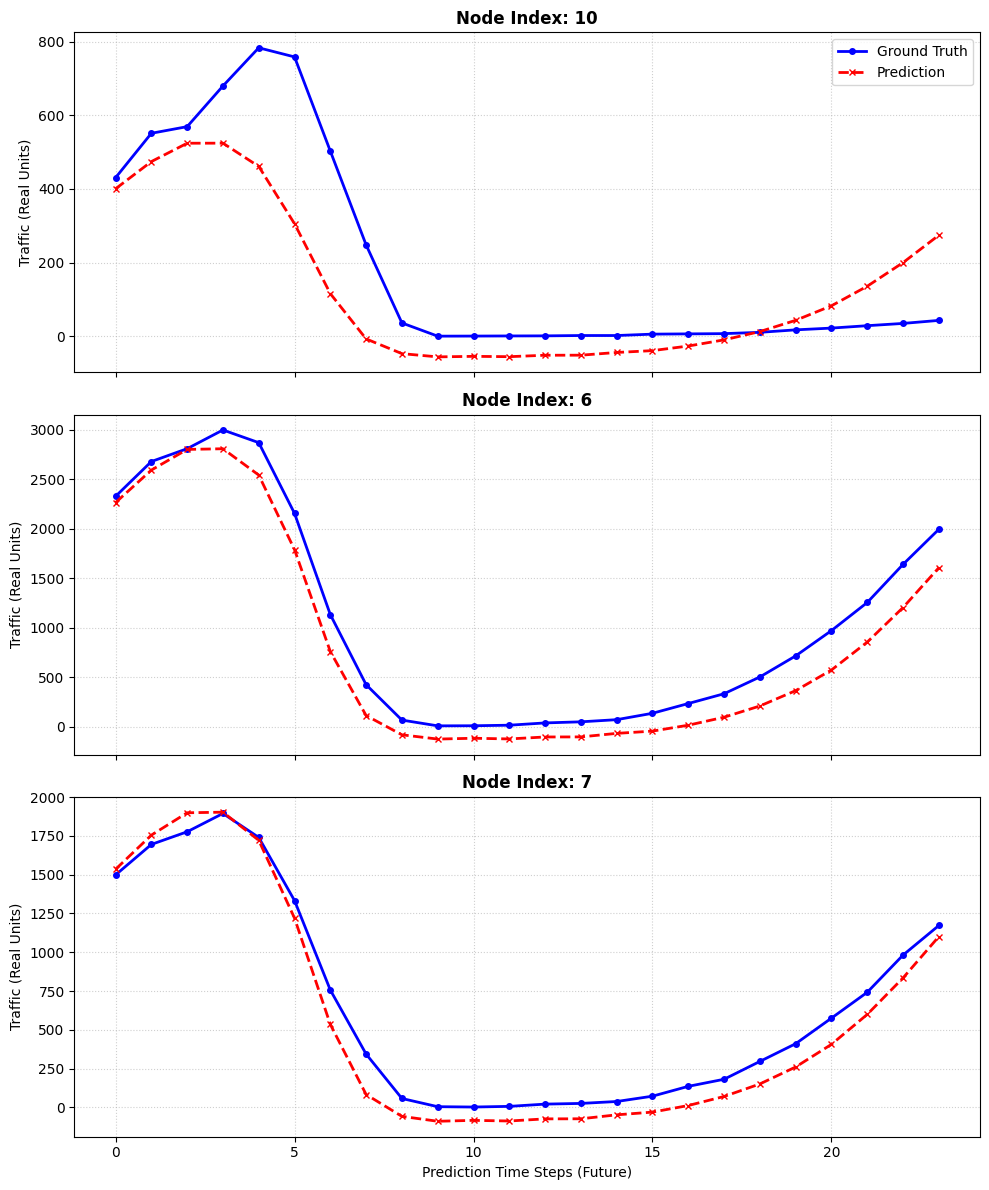

The last date is 2024-06-28 23:00:00


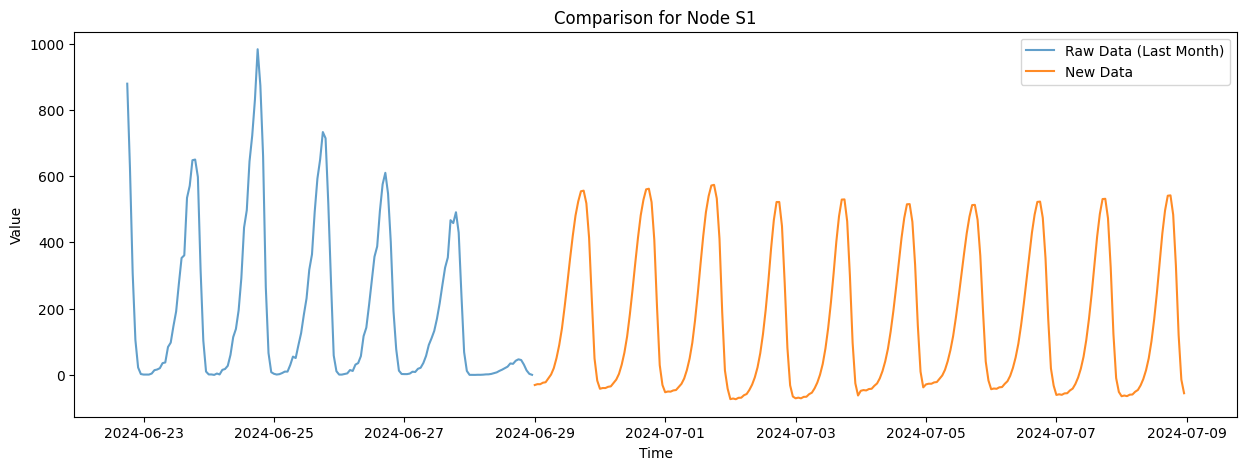

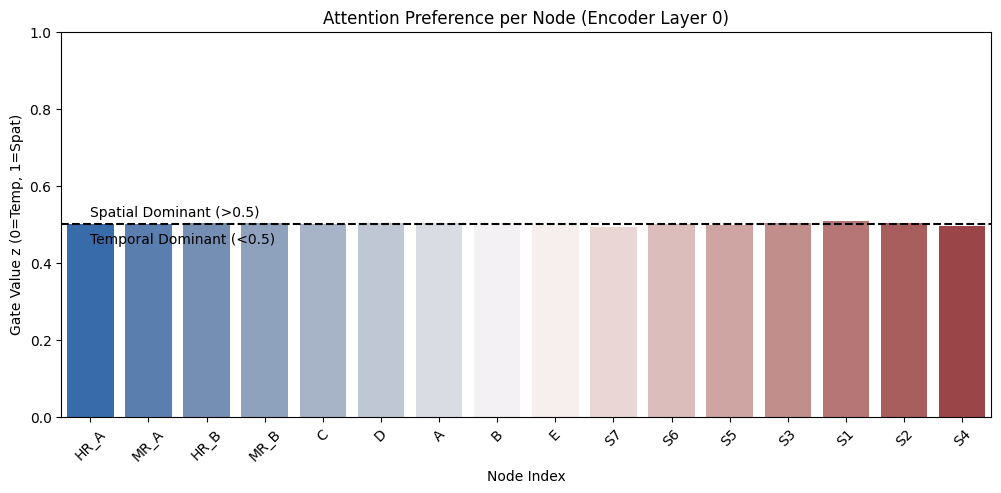

Spatial Attention Weights


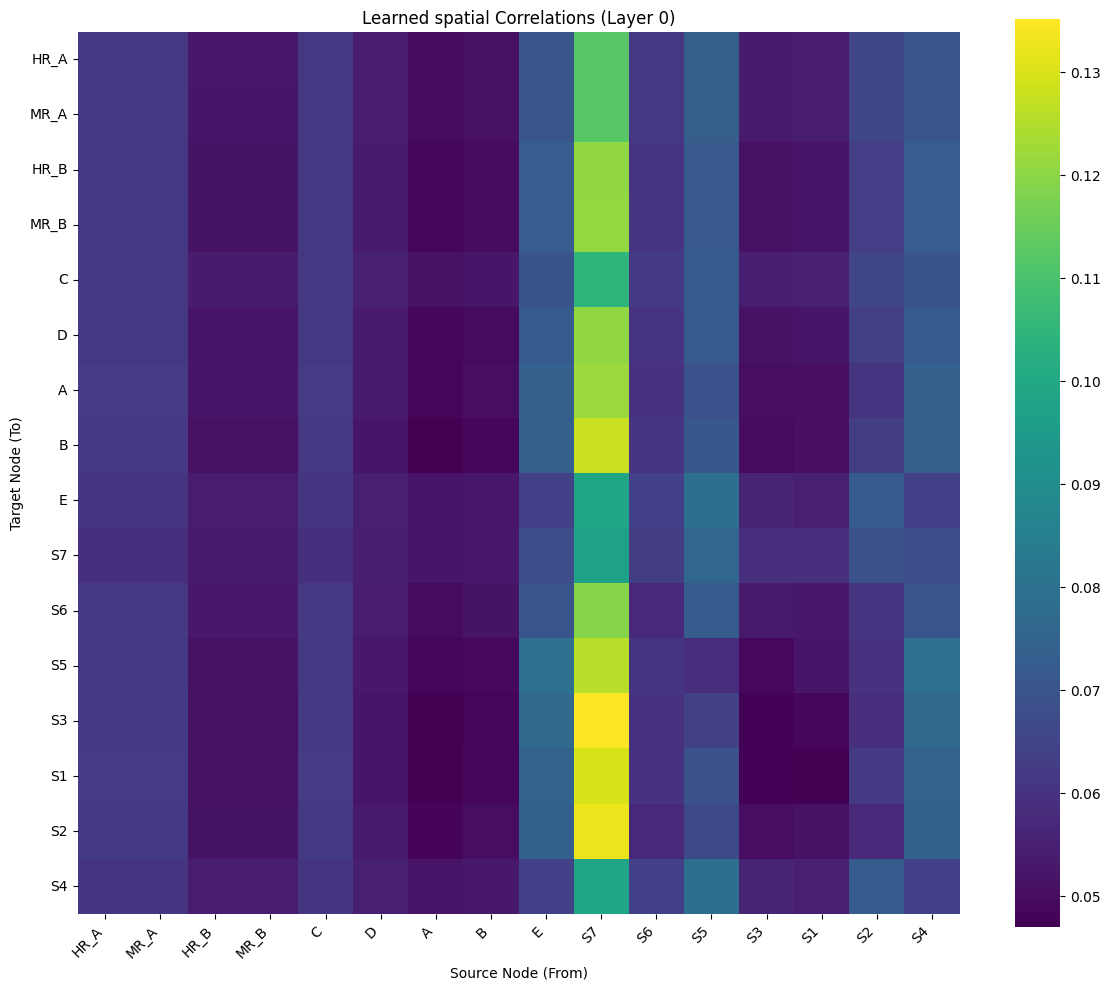

In [28]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = None
)

PREFIX_MODEL = 'model_zero'
print(f"Retrieving model from {PREFIX_MODEL}_trained.pth")
state_dict = torch.load(f'{PREFIX_MODEL}_trained.pth')
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, 'cpu')
validate_plots(MODEL, TSS_VAL_DL, 'cpu', num_nodes_to_plot=3)
plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS,10)
analyze_attention_preference(MODEL,TSS_VAL_DL, layer_index=0, node_list=NODE_LIST, device='cpu')
plot_att_matrix_correlations(MODEL, TSS_VAL_DL, type_attn='spatial', node_names=NODE_LIST, layer_idx=0, device='cpu')
#plot_att_matrix_correlations(MODEL, TSS_VAL_DL, type_attn='temporal', node_names=NODE_LIST, layer_idx=0, device='cpu')

### MODEL WITH ATT MASK

✅ Spatial Mask Enabled.
ℹ️ Node Mask Disabled.
Retrieving model from model_att_mask_trained.pth
Validation Complete.
MAE:  412.2714 (Real Units)
RMSE: 564.5846 (Real Units)
MAPE: 2929.34%
📊 Visualization for Batch Sample #6


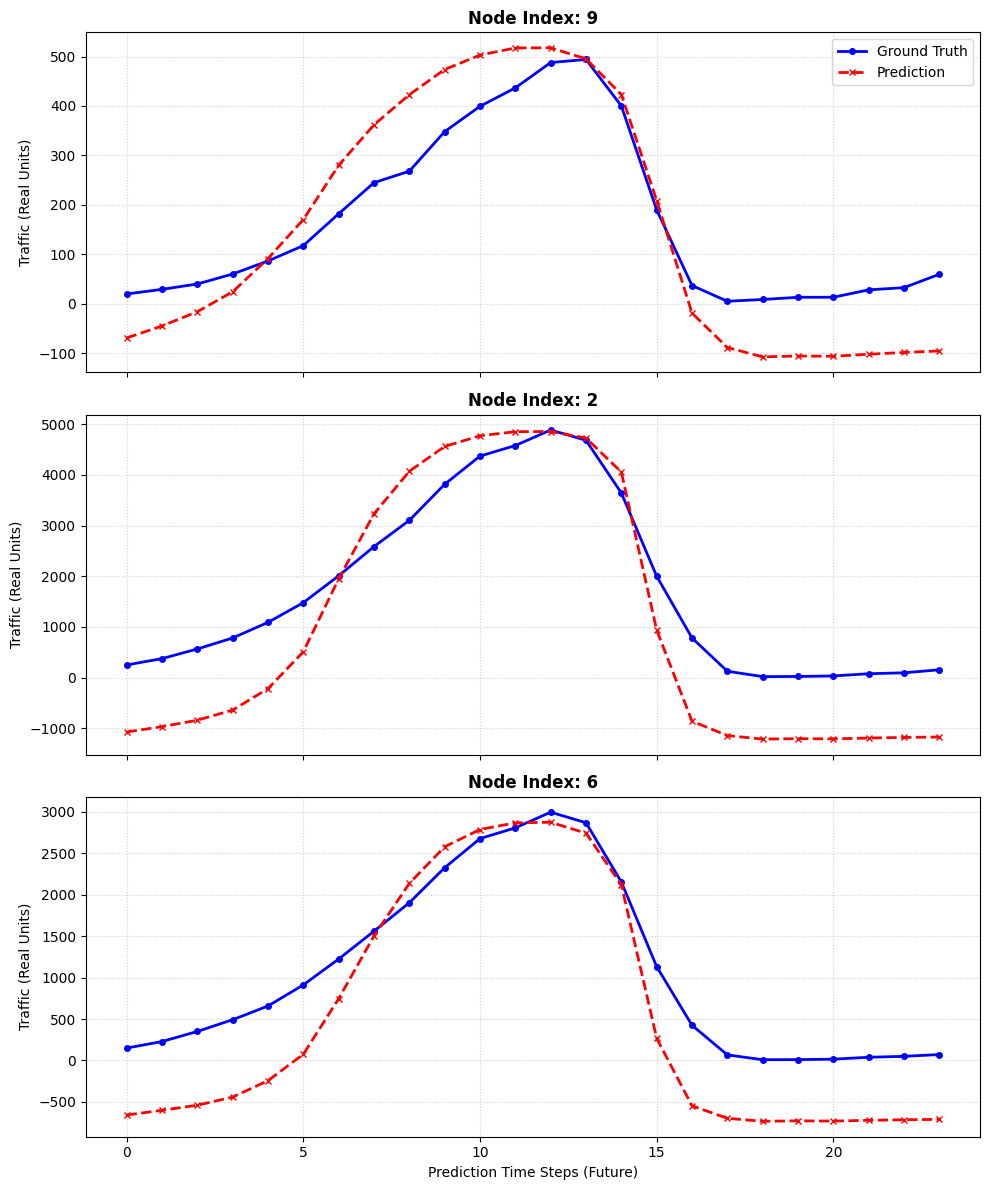

The last date is 2024-06-28 23:00:00


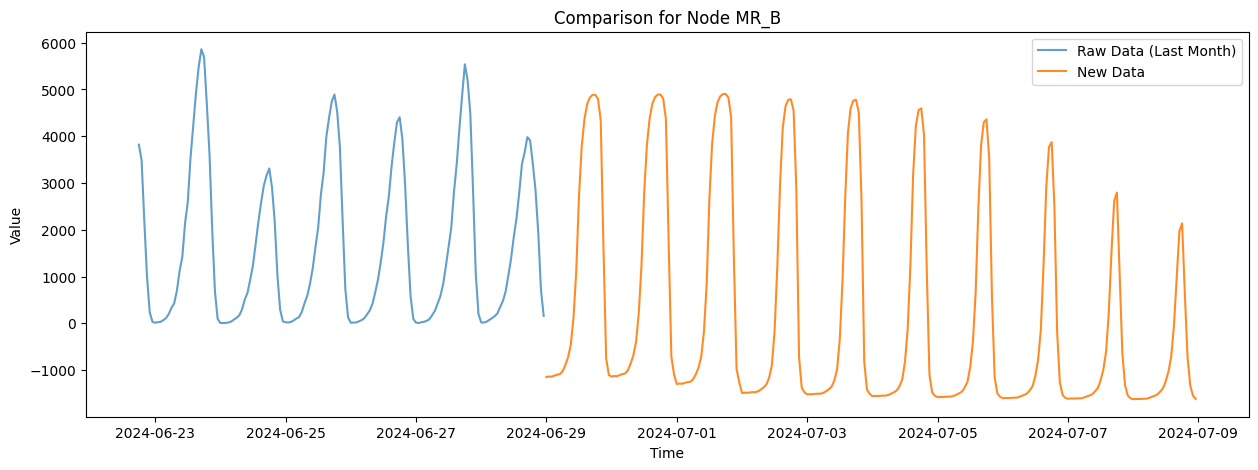

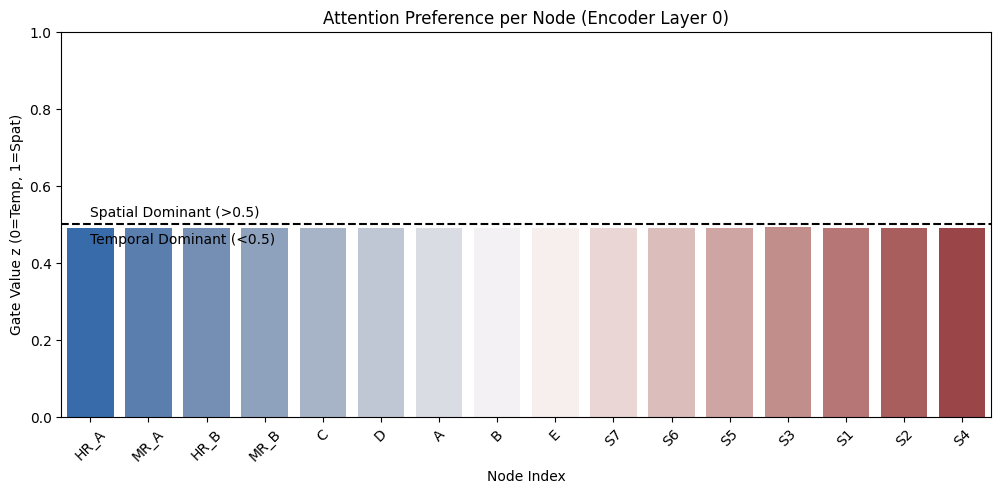

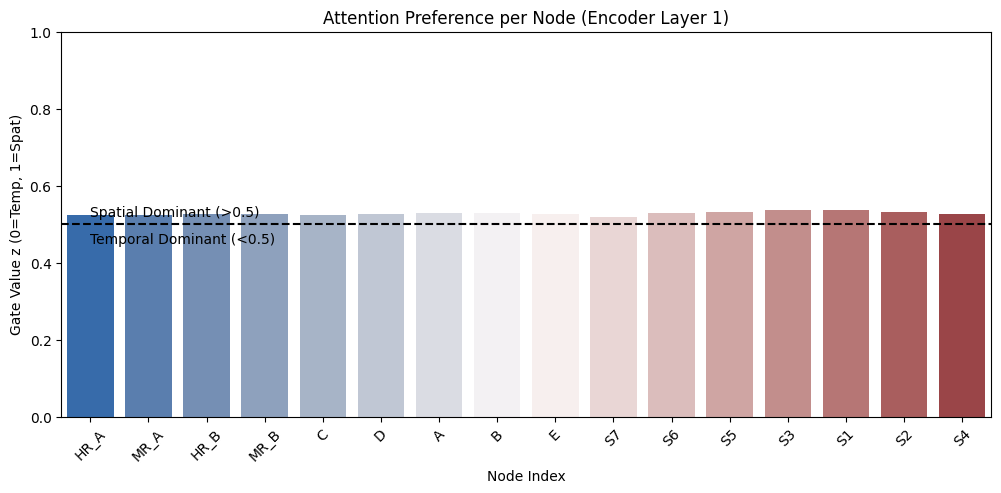

NameError: name 'plot_spatial_correlations' is not defined

In [29]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = ATT_MASK_T
)

PREFIX_MODEL = 'model_att_mask'
print(f"Retrieving model from {PREFIX_MODEL}_trained.pth")
state_dict = torch.load(f'{PREFIX_MODEL}_trained.pth')
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, 'cpu')
validate_plots(MODEL, TSS_VAL_DL, 'cpu', num_nodes_to_plot=3)
plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS,10)
analyze_attention_preference(MODEL,TSS_VAL_DL, layer_index=0, node_list=NODE_LIST, device='cpu')
analyze_attention_preference(MODEL,TSS_VAL_DL, layer_index=1, node_list=NODE_LIST, device='cpu')
plot_spatial_correlations(MODEL, TSS_VAL_DL, node_names=NODE_LIST, layer_idx=0, device='cpu')
plot_spatial_correlations(MODEL, TSS_VAL_DL, node_names=NODE_LIST, layer_idx=1, device='cpu')
print()

## MODEL PHYSICS LOSS

✅ Spatial Mask Enabled.
✅ Node Mask Enabled.
Retrieving model from model_att_phy_mask_trained.pth
Validation Complete.
MAE:  154.0908 (Real Units)
RMSE: 273.1978 (Real Units)
MAPE: 307.15%
📊 Visualization for Batch Sample #6


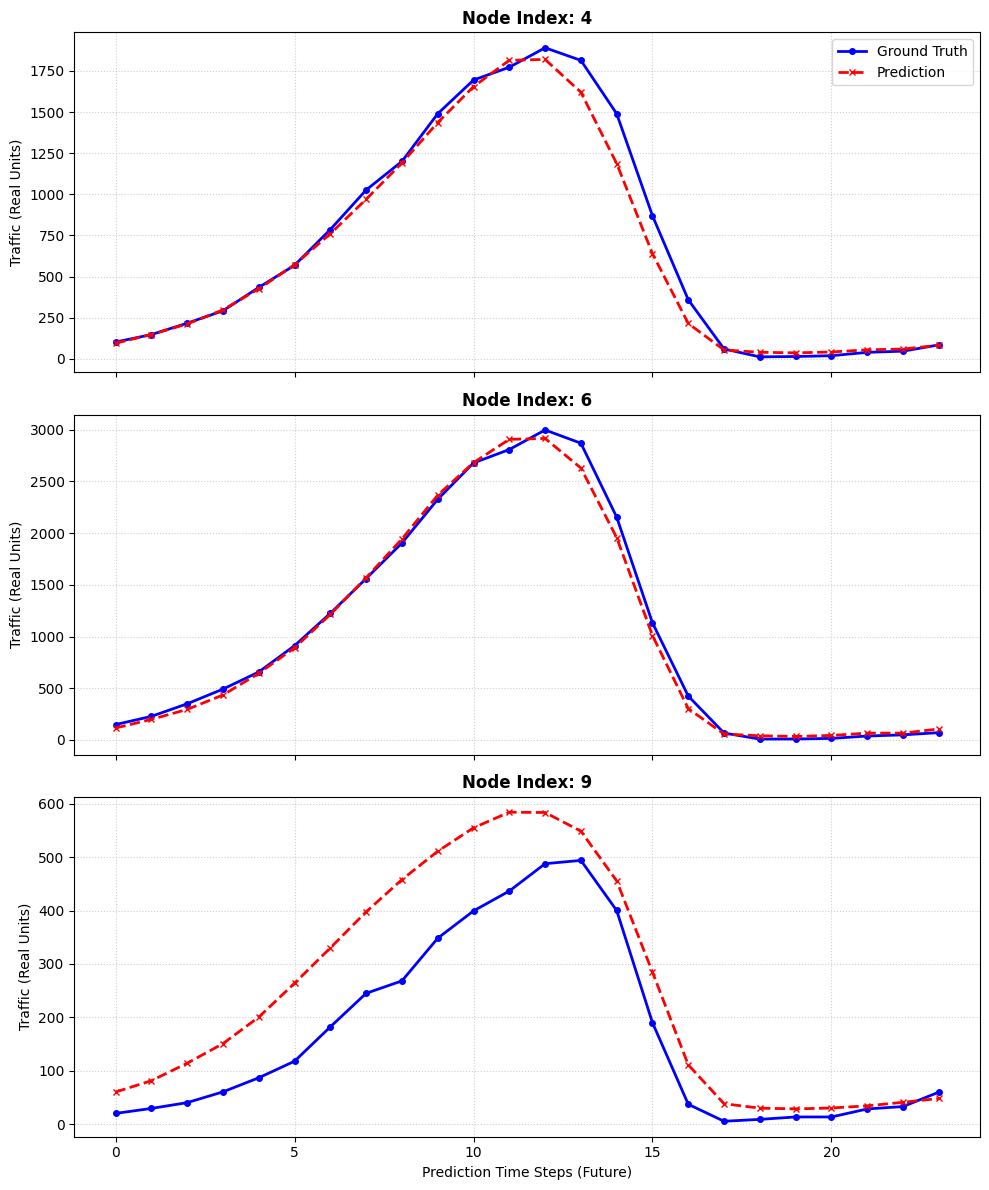

The last date is 2024-06-28 23:00:00


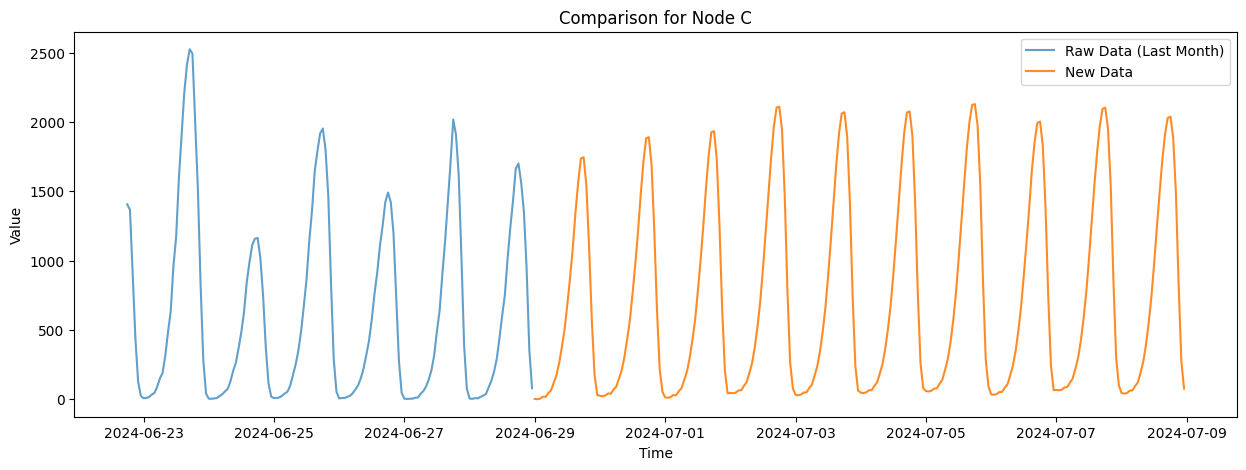

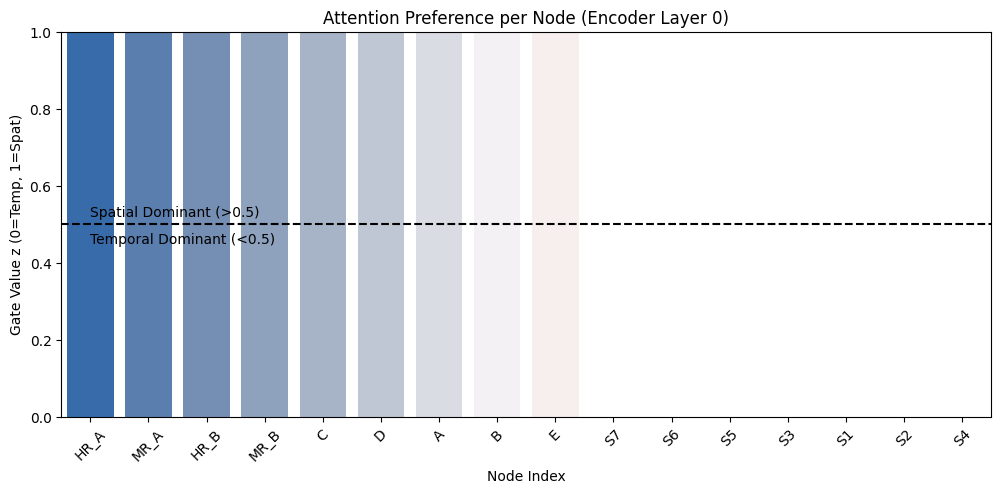

NameError: name 'plot_spatial_correlations' is not defined

In [30]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = ATT_MASK_T,
        node_mask = LEAF_NODES_MASK_T
)


PREFIX_MODEL = 'model_att_phy_mask'
print(f"Retrieving model from {PREFIX_MODEL}_trained.pth")
state_dict = torch.load(f'{PREFIX_MODEL}_trained.pth')
MODEL.load_state_dict(state_dict)

validate_model(MODEL, TSS_VAL_DL, 'cpu')
validate_plots(MODEL, TSS_VAL_DL, 'cpu', num_nodes_to_plot=3)
plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS, 10)
analyze_attention_preference(MODEL,TSS_VAL_DL, layer_index=0, node_list=NODE_LIST, device='cpu')
plot_spatial_correlations(MODEL, TSS_VAL_DL, node_names=NODE_LIST, layer_idx=0, device='cpu')
print()

# SIMULTATION

In [31]:
     
def train_model_physics_masked(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs=30, leaf_node_mask=None):

    leaf_mask_ext = leaf_node_mask.clone().view(1, 1, -1, 1).to(device)
    inner_nodes = ~leaf_node_mask.bool()*1
    
    print("Starting Training...")


    for epoch in range(epochs):
        print(f"Epoch [{epoch+1}/{epochs}]")
        # Train
        model.train()
        total_loss = 0
        total_mse_loss = 0
        total_phy_loss = 0

        for batch_idx, (X, TE, Y) in enumerate(train_loader):
            X, TE, Y = X.to(device), TE.to(device), Y.to(device)
            X_masked = X * leaf_mask_ext

            optimizer.zero_grad()
            preds = model(X_masked, TE)

            preds_inner = preds[:, :, inner_nodes, :]
            Y_inner = Y[:, :, inner_nodes, :]
            
            loss, mse_val, phy_val = loss_fn(preds_inner, Y_inner)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_mse_loss += mse_val
            total_phy_loss += phy_val
            
        avg_train_loss = total_loss / len(train_loader)
        avg_mse_loss = total_mse_loss / len(train_loader)
        avg_phy_loss = total_phy_loss / len(train_loader)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}, MSE Loss: {avg_mse_loss:.4f}, Physics Loss: {avg_phy_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0
        val_mse_loss = 0
        val_phy_loss = 0
        with torch.no_grad():
            for batch_idx, (X, TE, Y) in enumerate(val_loader):
                X, TE, Y = X.to(device), TE.to(device), Y.to(device)
                X_masked = X * leaf_mask_ext

                preds = model(X_masked, TE)

                preds_inner = preds[:, :, inner_nodes, :]
                Y_inner = Y[:, :, inner_nodes, :]

                loss, mse_val, phy_val = loss_fn(preds_inner, Y_inner)
                val_loss += loss.item()
                val_mse_loss += mse_val
                val_phy_loss += phy_val
                
        avg_val_loss = val_loss / len(val_loader)
        avg_val_mse_loss = val_mse_loss / len(val_loader)
        avg_val_phy_loss = val_phy_loss / len(val_loader)

        print(f"Epoch [{epoch+1}/{epochs}] - Validation Loss: {avg_val_loss:.4f}, MSE Loss: {avg_val_mse_loss:.4f}, Physics Loss: {avg_val_phy_loss:.4f}")
        
        # Early Stopping
        
        if early_stopping is not None:
            early_stopping(avg_val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping triggered. Training stopped.")
                break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

In [32]:
MODEL = GMAN(
        NODE_VECTORS,
        config,
        spatial_mask = ATT_MASK_T,
        node_mask = LEAF_NODES_MASK_T
).to(DEVICE)

PATIENCE = 20

PREFIX_MODEL = 'model_att_phy_mask_nodes'
CHECKPOINT_PATH = f'best_{PREFIX_MODEL}.pth'
early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = CombinedTrafficLoss(
        G_physical=G_router, 
        dataset=TSS_TRAIN_DS, 
        leaf_mask=LEAF_NODES_MASK_T,
        device=DEVICE, 
        lambda_phy=10  
)

✅ Spatial Mask Enabled.
✅ Node Mask Enabled.


In [33]:
MODEL = train_model_physics_masked(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS,
    leaf_node_mask=LEAF_NODES_MASK_T
)

torch.save(MODEL.state_dict(), f'{PREFIX_MODEL}_trained.pth')
print(f"Model saved to {PREFIX_MODEL}_trained.pth")

Starting Training...
Epoch [1/30]
Epoch [1/30] - Train Loss: 335480.7724, MSE Loss: 1.0520, Physics Loss: 33547.9688
Epoch [1/30] - Validation Loss: 307656.5262, MSE Loss: 0.9484, Physics Loss: 30765.5527
Validation loss decreased (inf --> 307656.526250).  Saving model ...
Epoch [2/30]
Epoch [2/30] - Train Loss: 237556.2473, MSE Loss: 0.8125, Physics Loss: 23755.5410
Epoch [2/30] - Validation Loss: 70135.0805, MSE Loss: 0.4428, Physics Loss: 7013.4634
Validation loss decreased (307656.526250 --> 70135.080547).  Saving model ...
Epoch [3/30]
Epoch [3/30] - Train Loss: 58691.6963, MSE Loss: 0.3606, Physics Loss: 5869.1328
Epoch [3/30] - Validation Loss: 57005.9545, MSE Loss: 0.3806, Physics Loss: 5700.5581
Validation loss decreased (70135.080547 --> 57005.954531).  Saving model ...
Epoch [4/30]
Epoch [4/30] - Train Loss: 51304.1796, MSE Loss: 0.2788, Physics Loss: 5130.3896
Epoch [4/30] - Validation Loss: 56523.1923, MSE Loss: 0.2934, Physics Loss: 5652.2905
Validation loss decreased (57

<Axes: >

<Axes: >

Offset: 2024-06-28 23:00:00
The last date is 2024-06-28 23:00:00
Node Selected: S4 -> 15


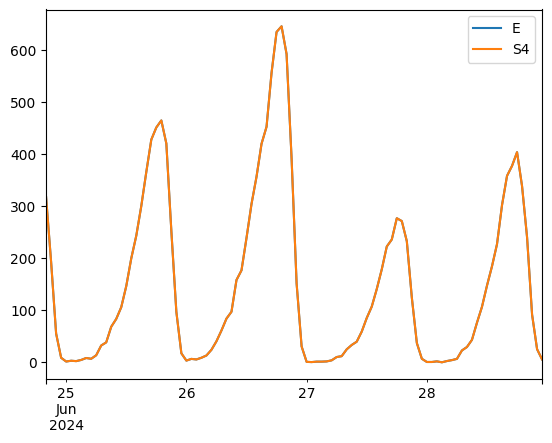

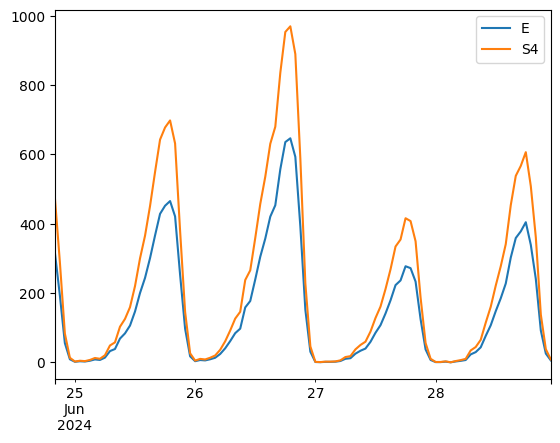

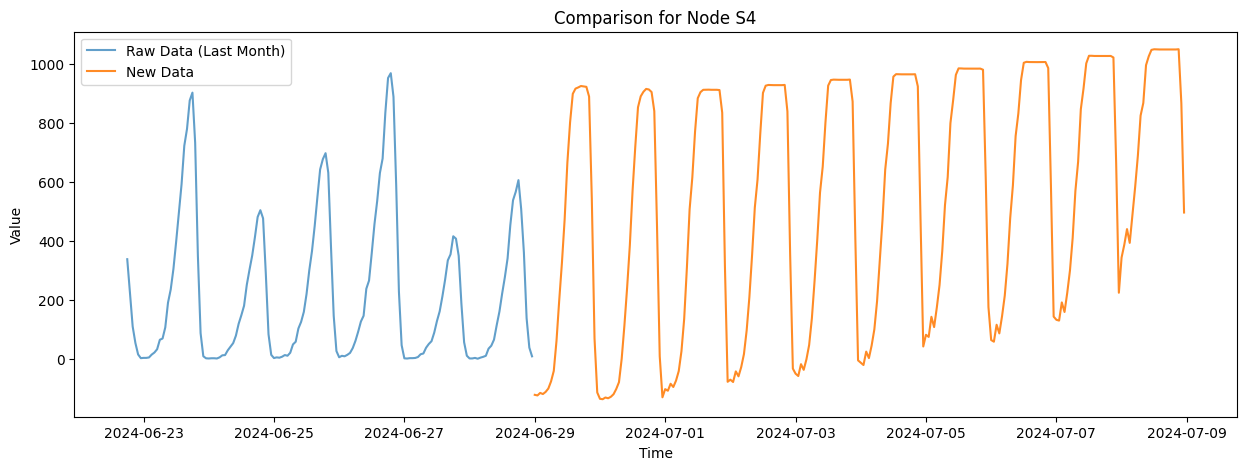

The last date is 2024-06-28 23:00:00
Node Selected: E -> 8


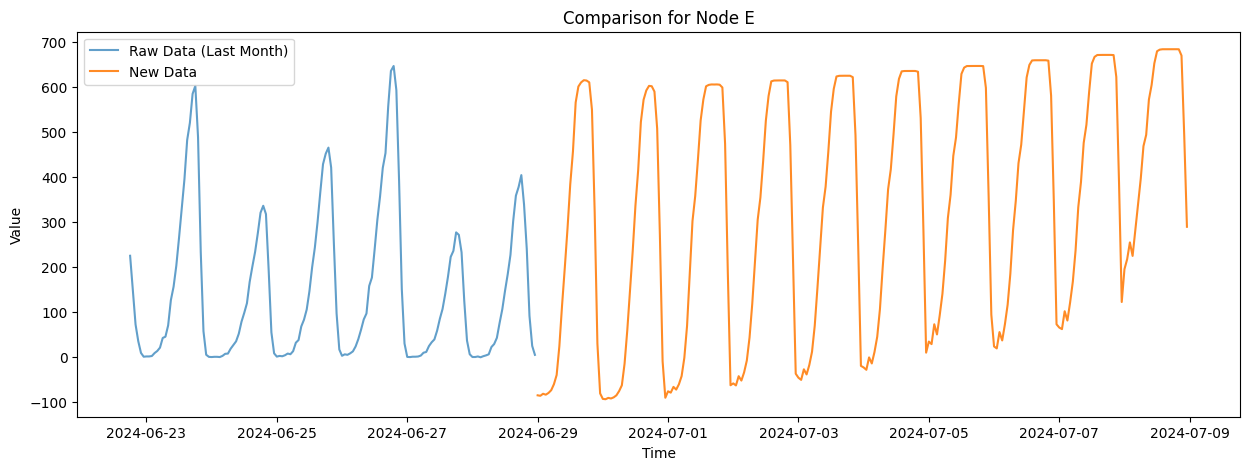

In [35]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION[DATA_RAW_SIMULATION.index >= (DATA_RAW_SIMULATION.index.max() - pd.DateOffset(months=1))]

## LAST MONTH
past_window = DATA_RAW_SIMULATION.index[-100:]
display(DATA_RAW_SIMULATION.loc[past_window,['E','S4']].plot())
DATA_RAW_SIMULATION.loc[:,'S4'] *= 1.5
display(DATA_RAW_SIMULATION.loc[past_window,['E','S4']].plot())

OFF_SET = DATA_RAW_SIMULATION.index.max()
print(f"Offset: {OFF_SET}")

plot_prediction(MODEL, DATA_RAW_SIMULATION, HIST_STEPS, PRED_STEPS, 10, node_selected='S4', leaf_mask=None)
plot_prediction(MODEL, DATA_RAW_SIMULATION, HIST_STEPS, PRED_STEPS, 10, node_selected='E', leaf_mask=None)#LEAF_NODES_MASK_T
print()
